# 🏠 House Price Prediction Project

## 0.1 Problem Definition

In this project, we are going to build a **regression machine learning model** to predict house prices.

The goal is to use the given dataset and its features to train a model that can estimate the final sale price of a house.

## 0.2 Target Column

Our target column is:

`SalePrice`

This is the value that our model will try to predict.

## 0.3 Dataset Overview

The dataset contains:

- **Rows:** 1460
- **Columns:** 81
- **Dataset source:** Kaggle

## 0.4 Column Types

### 0.4.1 ID-like Column

Count: 1

`Id`

### 0.4.2 Year-like Columns

Count: 4

`YearBuilt`,`YearRemodAdd`,`GarageYrBlt`,`YrSold`

### 0.4.3 Month-like Column

Count: 1

`MoSold`

### 0.4.4 Categorical / Ordinal Categorical Columns

Count: 46

`MSSubClass`,`MSZoning`,`Street`,`Alley`,`LotShape`,`LandContour`,`Utilities`,`LotConfig`,`LandSlope`,`Neighborhood`,`Condition1`,`Condition2`,`BldgType`,`HouseStyle`,`OverallQual`,`OverallCond`,`RoofStyle`,`RoofMatl`,`Exterior1st`,`Exterior2nd`,`MasVnrType`,`ExterQual`,`ExterCond`,`Foundation`,`BsmtQual`,`BsmtCond`,`BsmtExposure`,`BsmtFinType1`,`BsmtFinType2`,`Heating`,`HeatingQC`,`CentralAir`,`Electrical`,`KitchenQual`,`Functional`,`FireplaceQu`,`GarageType`,`GarageFinish`,`GarageQual`,`GarageCond`,`PavedDrive`,`PoolQC`,`Fence`,`MiscFeature`,`SaleType`,`SaleCondition`

### 0.4.5 Numerical Columns

Count: 28

`LotFrontage`,`LotArea`,`MasVnrArea`,`BsmtFinSF1`,`BsmtFinSF2`,`BsmtUnfSF`,`TotalBsmtSF`,`1stFlrSF`,`2ndFlrSF`,`LowQualFinSF`,`GrLivArea`,`BsmtFullBath`,`BsmtHalfBath`,`FullBath`,`HalfBath`,`BedroomAbvGr`,`KitchenAbvGr`,`TotRmsAbvGrd`,`Fireplaces`,`GarageCars`,`GarageArea`,`WoodDeckSF`,`OpenPorchSF`,`EnclosedPorch`,`3SsnPorch`,`ScreenPorch`,`PoolArea`,`MiscVal`

### 0.4.6 Target Column

Count: 1

`SalePrice`

## 0.5 Summary

| Column Type | Count |
|---|---:|
| ID-like | 1 |
| Year-like | 4 |
| Month-like | 1 |
| Categorical / Ordinal Categorical | 46 |
| Numerical | 28 |
| Target | 1 |
| Total Columns | 81 |

## 0.6 Project Goal

The main goal of this project is to understand the relationship between house features and sale price, then build a machine learning model that can predict house prices accurately.

# 1. Basic Dataset Review
In this section, we will explore the dataset to get a basic understanding of its structure, columns, data types, missing values, and overall quality.

## 1.1 Import all libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 1.2 import train and test file

In [2]:
train_df = pd.read_csv(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\Data\train.csv")
test_df = pd.read_csv(r"C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Machine_Learning\House-Price-Prediction-Regression\Data\test.csv")

print(train_df.shape , test_df.shape)

(1460, 81) (1459, 80)


## 1.3 Column report

In [3]:
def column_summary(df):
    return {
        "total_columns": len(df.columns),
        "columns": list(df.columns),
        "duplicate_columns": df.columns[df.columns.duplicated()].tolist(),
        "columns_with_spaces": [col for col in df.columns if isinstance(col, str) and col != col.strip()],
        "unnamed_columns": [col for col in df.columns if isinstance(col, str) and "Unnamed" in col],
        "non_string_columns": [col for col in df.columns if not isinstance(col, str)]
    }


In [4]:
column_summary(train_df)

{'total_columns': 81,
 'columns': ['Id',
  'MSSubClass',
  'MSZoning',
  'LotFrontage',
  'LotArea',
  'Street',
  'Alley',
  'LotShape',
  'LandContour',
  'Utilities',
  'LotConfig',
  'LandSlope',
  'Neighborhood',
  'Condition1',
  'Condition2',
  'BldgType',
  'HouseStyle',
  'OverallQual',
  'OverallCond',
  'YearBuilt',
  'YearRemodAdd',
  'RoofStyle',
  'RoofMatl',
  'Exterior1st',
  'Exterior2nd',
  'MasVnrType',
  'MasVnrArea',
  'ExterQual',
  'ExterCond',
  'Foundation',
  'BsmtQual',
  'BsmtCond',
  'BsmtExposure',
  'BsmtFinType1',
  'BsmtFinSF1',
  'BsmtFinType2',
  'BsmtFinSF2',
  'BsmtUnfSF',
  'TotalBsmtSF',
  'Heating',
  'HeatingQC',
  'CentralAir',
  'Electrical',
  '1stFlrSF',
  '2ndFlrSF',
  'LowQualFinSF',
  'GrLivArea',
  'BsmtFullBath',
  'BsmtHalfBath',
  'FullBath',
  'HalfBath',
  'BedroomAbvGr',
  'KitchenAbvGr',
  'KitchenQual',
  'TotRmsAbvGrd',
  'Functional',
  'Fireplaces',
  'FireplaceQu',
  'GarageType',
  'GarageYrBlt',
  'GarageFinish',
  'GarageC

> good sign: there are no `duplicate column` , `columns_with_no_space` , `unnamed_columns` , `non_string_columns` 

## 1.4 Datatypes checking 

In [5]:
import pandas as pd
import numpy as np

from pandas.api.types import (
    is_numeric_dtype,
    is_bool_dtype,
    is_datetime64_any_dtype,
    is_object_dtype,
    is_string_dtype
)


def create_dtype_report(
    df,
    id_cols=None,
    target_cols=None,
    year_cols=None,
    month_cols=None,
    categorical_overrides=None,
    text_length_threshold=50,
    categorical_unique_threshold=30,
    show_report=True
):
    """
    Create a clean data type report.

    Step 1: Automatically detect columns using pandas dtype.
    Step 2: Apply manual correction for semantic columns like year, month, id, target, etc.

    Parameters:
        df: pandas DataFrame
        id_cols: list of ID-like columns
        target_cols: list of target columns
        year_cols: list of year-like columns
        month_cols: list of month-like columns
        categorical_overrides: list of numeric-looking but categorical columns
        text_length_threshold: average string length threshold to detect text columns
        categorical_unique_threshold: unique value threshold for object categorical columns
        show_report: if True, prints the final report

    Returns:
        final_report: dictionary of grouped columns
        column_summary: DataFrame with column-level details
    """

    # -----------------------------
    # Manual column groups
    # -----------------------------
    id_cols = id_cols or []
    target_cols = target_cols or []
    year_cols = year_cols or []
    month_cols = month_cols or []
    categorical_overrides = categorical_overrides or []

    manual_cols = set(
        id_cols +
        target_cols +
        year_cols +
        month_cols +
        categorical_overrides
    )

    # Keep only columns that actually exist in df
    def valid_cols(cols):
        return [col for col in cols if col in df.columns]

    id_cols = valid_cols(id_cols)
    target_cols = valid_cols(target_cols)
    year_cols = valid_cols(year_cols)
    month_cols = valid_cols(month_cols)
    categorical_overrides = valid_cols(categorical_overrides)


    # Auto detection using pandas

    auto_report = {
        "numeric": [],
        "categorical": [],
        "datetime": [],
        "text": [],
        "bool": [],
        "object": []
    }

    summary_rows = []

    for col in df.columns:
        series = df[col]
        dtype = series.dtype
        missing_count = series.isnull().sum()
        unique_count = series.nunique(dropna=True)

        detected_type = None

        if is_bool_dtype(series):
            detected_type = "bool"
            auto_report["bool"].append(col)

        elif is_datetime64_any_dtype(series):
            detected_type = "datetime"
            auto_report["datetime"].append(col)

        elif is_numeric_dtype(series):
            detected_type = "numeric"
            auto_report["numeric"].append(col)

        elif is_object_dtype(series) or is_string_dtype(series):
            auto_report["object"].append(col)

            avg_text_length = series.dropna().astype(str).str.len().mean()

            if avg_text_length >= text_length_threshold:
                detected_type = "text"
                auto_report["text"].append(col)

            elif unique_count <= categorical_unique_threshold:
                detected_type = "categorical"
                auto_report["categorical"].append(col)

            else:
                detected_type = "categorical"
                auto_report["categorical"].append(col)

        else:
            detected_type = "object"
            auto_report["object"].append(col)

        summary_rows.append({
            "column": col,
            "pandas_dtype": dtype,
            "auto_detected_type": detected_type,
            "missing_values": missing_count,
            "unique_values": unique_count
        })

    column_summary = pd.DataFrame(summary_rows)


    # Remove manual columns from auto groups
    manual_cols = set(
        id_cols +
        target_cols +
        year_cols +
        month_cols +
        categorical_overrides
    )

    for group in auto_report:
        auto_report[group] = [
            col for col in auto_report[group]
            if col not in manual_cols
        ]


    # Final corrected report

    final_report = {
        "id_like": id_cols,
        "target": target_cols,
        "year_like": year_cols,
        "month_like": month_cols,
        "numeric": auto_report["numeric"],
        "categorical": categorical_overrides + auto_report["categorical"],
        "datetime": auto_report["datetime"],
        "text": auto_report["text"],
        "bool": auto_report["bool"],
        "object_dtype_columns": auto_report["object"]
    }


    # Add final corrected type to summary

    final_type_map = {}

    for dtype_group, cols in final_report.items():
        for col in cols:
            final_type_map[col] = dtype_group

    column_summary["final_corrected_type"] = column_summary["column"].map(final_type_map)


    # Print report

    if show_report:
        print("=" * 70)
        print("FINAL DATA TYPE REPORT")
        print("=" * 70)

        for group_name, cols in final_report.items():
            print(f"\n{group_name.upper()}")
            print(f"Count: {len(cols)}")

            if cols:
                print(",".join([f"`{col}`" for col in cols]))
            else:
                print("None")

        print("\n" + "=" * 70)
        print(f"Total columns in DataFrame: {df.shape[1]}")
        print(f"Total columns in report: {sum(len(cols) for cols in final_report.values())}")
        print("=" * 70)

    return final_report, column_summary

In [6]:
house_dtype_report, house_column_summary = create_dtype_report(
    train_df,

    id_cols=[
        "Id"
    ],

    target_cols=[
        "SalePrice"
    ],

    year_cols=[
        "YearBuilt",
        "YearRemodAdd",
        "GarageYrBlt",
        "YrSold"
    ],

    month_cols=[
        "MoSold"
    ],

    categorical_overrides=[
        "MSSubClass",
        "OverallQual",
        "OverallCond"
    ]
)



FINAL DATA TYPE REPORT

ID_LIKE
Count: 1
`Id`

TARGET
Count: 1
`SalePrice`

YEAR_LIKE
Count: 4
`YearBuilt`,`YearRemodAdd`,`GarageYrBlt`,`YrSold`

MONTH_LIKE
Count: 1
`MoSold`

NUMERIC
Count: 28
`LotFrontage`,`LotArea`,`MasVnrArea`,`BsmtFinSF1`,`BsmtFinSF2`,`BsmtUnfSF`,`TotalBsmtSF`,`1stFlrSF`,`2ndFlrSF`,`LowQualFinSF`,`GrLivArea`,`BsmtFullBath`,`BsmtHalfBath`,`FullBath`,`HalfBath`,`BedroomAbvGr`,`KitchenAbvGr`,`TotRmsAbvGrd`,`Fireplaces`,`GarageCars`,`GarageArea`,`WoodDeckSF`,`OpenPorchSF`,`EnclosedPorch`,`3SsnPorch`,`ScreenPorch`,`PoolArea`,`MiscVal`

CATEGORICAL
Count: 46
`MSSubClass`,`OverallQual`,`OverallCond`,`MSZoning`,`Street`,`Alley`,`LotShape`,`LandContour`,`Utilities`,`LotConfig`,`LandSlope`,`Neighborhood`,`Condition1`,`Condition2`,`BldgType`,`HouseStyle`,`RoofStyle`,`RoofMatl`,`Exterior1st`,`Exterior2nd`,`MasVnrType`,`ExterQual`,`ExterCond`,`Foundation`,`BsmtQual`,`BsmtCond`,`BsmtExposure`,`BsmtFinType1`,`BsmtFinType2`,`Heating`,`HeatingQC`,`CentralAir`,`Electrical`,`Kitchen

In [7]:
house_column_summary

,column,pandas_dtype,auto_detected_type,missing_values,unique_values,final_corrected_type
0,Id,int64,numeric,0,1460,id_like
1,MSSubClass,int64,numeric,0,15,categorical
2,MSZoning,object,categorical,0,5,object_dtype_columns
3,LotFrontage,float64,numeric,259,110,numeric
4,LotArea,int64,numeric,0,1073,numeric
5,Street,object,categorical,0,2,object_dtype_columns
6,Alley,object,categorical,1369,2,object_dtype_columns
7,LotShape,object,categorical,0,4,object_dtype_columns
8,LandContour,object,categorical,0,4,object_dtype_columns
9,Utilities,object,categorical,0,2,object_dtype_columns


Initially, pandas detected **38 numeric columns** and **43 categorical/object columns** based on data types.
However, some columns like `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold`, `MoSold`, `MSSubClass`, `OverallQual`, and `OverallCond` needed manual correction.
After applying the manual approach, we finalized **28 numerical columns**, **46 categorical/ordinal categorical columns**, **4 year-like columns**, **1 month-like column**, **1 ID column**, and **1 target column**.

### Missing unique summary

In [8]:
# Missing + unique value summary
missing_unique_summary = pd.DataFrame({
    "column": train_df.columns,
    "missing_values": train_df.isnull().sum().values,
    "missing_percentage": (train_df.isnull().mean().values * 100).round(2),
    "unique_values": train_df.nunique(dropna=True).values,
    "unique_percentage": ((train_df.nunique(dropna=True).values / len(train_df)) * 100).round(2)
})

missing_unique_summary

,column,missing_values,missing_percentage,unique_values,unique_percentage
0,Id,0,0.00,1460,100.00
1,MSSubClass,0,0.00,15,1.03
2,MSZoning,0,0.00,5,0.34
3,LotFrontage,259,17.74,110,7.53
4,LotArea,0,0.00,1073,73.49
5,Street,0,0.00,2,0.14
6,Alley,1369,93.77,2,0.14
7,LotShape,0,0.00,4,0.27
8,LandContour,0,0.00,4,0.27
9,Utilities,0,0.00,2,0.14


In [9]:
# Remove old columns if they already exist, then merge updated info
cols_to_drop = [
    "missing_values",
    "missing_percentage",
    "unique_values",
    "unique_percentage"
]

house_column_summary = house_column_summary.drop(
    columns=[col for col in cols_to_drop if col in house_column_summary.columns]
)

house_column_summary = house_column_summary.merge(
    missing_unique_summary,
    on="column",
    how="left"
)

house_column_summary.head()

,column,pandas_dtype,auto_detected_type,final_corrected_type,missing_values,missing_percentage,unique_values,unique_percentage
0,Id,int64,numeric,id_like,0,0.00,1460,100.00
1,MSSubClass,int64,numeric,categorical,0,0.00,15,1.03
2,MSZoning,object,categorical,object_dtype_columns,0,0.00,5,0.34
3,LotFrontage,float64,numeric,numeric,259,17.74,110,7.53
4,LotArea,int64,numeric,numeric,0,0.00,1073,73.49


In [10]:
house_column_summary.sort_values(
    by="missing_percentage",
    ascending=False
).head(20)

,column,pandas_dtype,auto_detected_type,final_corrected_type,missing_values,missing_percentage,unique_values,unique_percentage
72,PoolQC,object,categorical,object_dtype_columns,1453,99.52,3,0.21
74,MiscFeature,object,categorical,object_dtype_columns,1406,96.30,4,0.27
6,Alley,object,categorical,object_dtype_columns,1369,93.77,2,0.14
73,Fence,object,categorical,object_dtype_columns,1179,80.75,4,0.27
25,MasVnrType,object,categorical,object_dtype_columns,872,59.73,3,0.21
57,FireplaceQu,object,categorical,object_dtype_columns,690,47.26,5,0.34
3,LotFrontage,float64,numeric,numeric,259,17.74,110,7.53
63,GarageQual,object,categorical,object_dtype_columns,81,5.55,5,0.34
60,GarageFinish,object,categorical,object_dtype_columns,81,5.55,3,0.21
58,GarageType,object,categorical,object_dtype_columns,81,5.55,6,0.41


From the top missing-value columns, most high-missing features are optional property features such as `PoolQC`, `MiscFeature`, `Alley`, and `Fence`, so these columns can be removed for a simple baseline model.
However, columns like `FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, and `BsmtExposure` should not be removed directly because missing values often mean "No Fireplace", "No Garage", or "No Basement".

In [11]:
house_column_summary.to_csv("1.House_column_summary.csv")

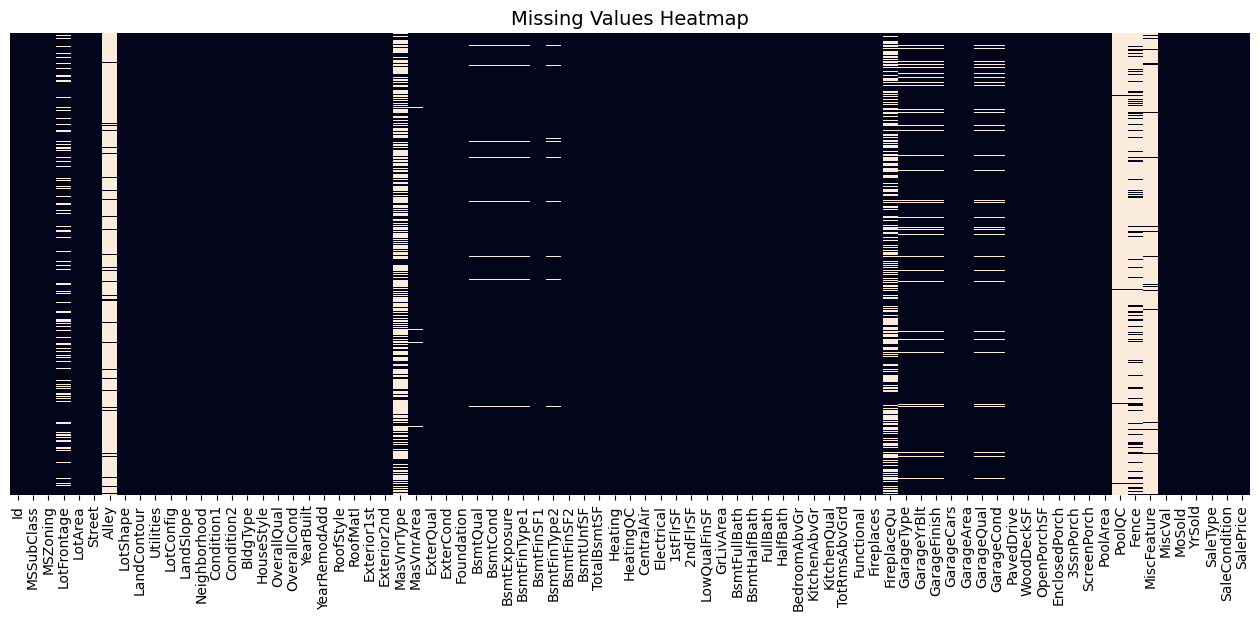

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 6))
sns.heatmap(train_df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Heatmap", fontsize=14)
plt.show()

The missingness matrix helps visualize the distribution and pattern of missing values across all features.
It is useful for identifying highly sparse columns, row-wise missing patterns, and whether missing values occur randomly or systematically.

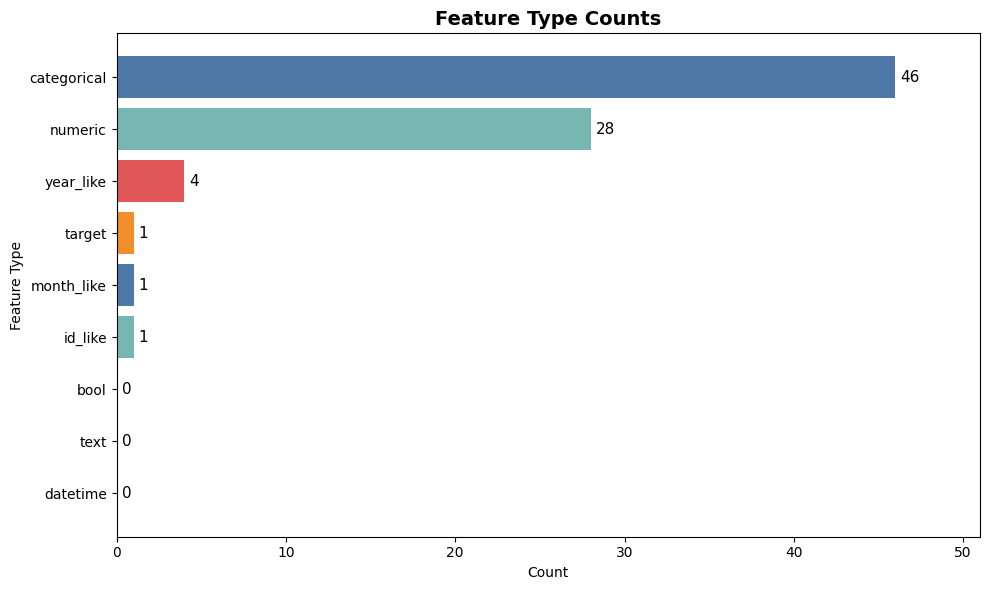

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature type counts from the final corrected report
feature_type_counts = {
    k: len(v)
    for k, v in house_dtype_report.items()
    if k != "object_dtype_columns"
}

feature_type_df = (
    pd.DataFrame(feature_type_counts.items(), columns=["feature_type", "count"])
    .sort_values("count", ascending=True)
)

# Modern Pro palette
colors = ["#4E79A7", "#F28E2C", "#E15759", "#76B7B2", "#4E79A7", "#F28E2C", "#E15759", "#76B7B2"][:len(feature_type_df)]

plt.figure(figsize=(10, 6))
bars = plt.barh(feature_type_df["feature_type"], feature_type_df["count"], color=colors)

plt.title("Feature Type Counts", fontsize=14, fontweight="bold")
plt.xlabel("Count")
plt.ylabel("Feature Type")

for bar in bars:
    plt.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{int(bar.get_width())}",
        va="center",
        fontsize=11
    )

plt.xlim(0, feature_type_df["count"].max() + 5)
plt.tight_layout()
plt.show()

## Basic Dataset Health Report

### Feature Type Summary
After manual correction, the dataset contains **46 categorical/ordinal categorical features**, **28 numerical features**, **4 year-like features**, **1 month-like feature**, **1 ID column**, and **1 target column**.  
There are no direct `datetime`, `text`, or `bool` type columns in the dataset.

### Initial Issues Before EDA
The main issue in this dataset is **missing values**, especially in optional property-related features.  
High-missing columns include `PoolQC`, `MiscFeature`, `Alley`, `Fence`, `MasVnrType`, and `FireplaceQu`.

### Issue-Based Feature Notes

| Feature Group | Columns | Issue | Recommended Action |
|---|---|---|---|
| Very high missing | `PoolQC`, `MiscFeature`, `Alley`, `Fence` | 80%+ missing values | Can be removed for a simple baseline model |
| High missing but meaningful | `FireplaceQu` | Missing likely means no fireplace | Fill with `None`, do not remove directly |
| Garage-related | `GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageQual`, `GarageCond` | Same missing count, likely no garage | Fill categorical with `None`, `GarageYrBlt` with `0` or median |
| Basement-related | `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2` | Missing likely means no basement | Fill with `None`, keep features |
| Numeric missing | `LotFrontage`, `MasVnrArea` | Numerical missing values | Fill with median or `0` depending on meaning |
| Low missing | `Electrical` | Only 1 missing value | Fill with mode |

### Features We Can Remove for Baseline
For a simple baseline model, we can remove:

`PoolQC`, `MiscFeature`, `Alley`, `Fence`

These features have extremely high missing percentages and may add noise at the beginning.

### Features We Should Not Remove Immediately
Do not remove these directly:

`FireplaceQu`, `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`, `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`

Their missing values may carry useful information such as **No Fireplace**, **No Garage**, or **No Basement**.

### Next Recommended Steps
1. Drop only very high-missing low-priority columns for baseline: `PoolQC`, `MiscFeature`, `Alley`, `Fence`.
2. Fill categorical missing values with `"None"` where missing means absence of that feature.
3. Fill numerical missing values using median or meaningful value like `0`.
4. Check target distribution of `SalePrice`.
5. Start univariate and bivariate EDA before model training.

## 2. Target Analysis

In this section, we will analyze the target column `SalePrice` to understand its missing values, data type, and basic statistical behavior.
This step helps us understand the price distribution before feature analysis and model building.

In [14]:
target_col = "SalePrice"

# Get target feature type from house_column_summary
target_feature_type = house_column_summary.loc[
    house_column_summary["column"] == target_col,
    "final_corrected_type"
].values[0]

target_series = train_df[target_col]

target_summary = ({
    "target_column": [target_col],
    "feature_type": [target_feature_type],
    "dtype": [target_series.dtype],
    "missing_count": [target_series.isnull().sum()],
    "missing_percentage": [round(target_series.isnull().mean() * 100, 2)],
    "min": [target_series.min()],
    "max": [target_series.max()],
    "mean": [round(target_series.mean(), 2)],
    "median": [target_series.median()],
    "mode": [target_series.mode()[0]],
    "std": [round(target_series.std(), 2)],
    "variance": [round(target_series.var(), 2)],
    "range": [target_series.max() - target_series.min()]
})

target_summary

{'target_column': ['SalePrice'],
 'feature_type': ['target'],
 'dtype': [dtype('int64')],
 'missing_count': [np.int64(0)],
 'missing_percentage': [np.float64(0.0)],
 'min': [np.int64(34900)],
 'max': [np.int64(755000)],
 'mean': [np.float64(180921.2)],
 'median': [np.float64(163000.0)],
 'mode': [np.int64(140000)],
 'std': [np.float64(79442.5)],
 'variance': [np.float64(6311111264.3)],
 'range': [np.int64(720100)]}

In [15]:
target_summary_df = pd.DataFrame(target_summary)
target_summary_df

,target_column,feature_type,dtype,missing_count,missing_percentage,min,max,mean,median,mode,std,variance,range
0,SalePrice,target,int64,0,0.0,34900,755000,180921.2,163000.0,140000,79442.5,6.311111e+09,720100


`SalePrice` has no missing values, is stored as an integer type, and shows a wide price range from 34,900 to 755,000, with the mean price higher than the median, indicating a right-skewed target distribution.

### 2.1 Target Distribution

In [16]:
target_col = "SalePrice"
target_series = train_df[target_col].dropna()

# Skewness and kurtosis
skewness_value = round(target_series.skew(), 3)
kurtosis_value = round(target_series.kurt(), 3)  # pandas uses Fisher's kurtosis, normal = 0


def get_skewness_shape(skewness):
    if skewness > 1:
        return "highly right-skewed"
    elif skewness > 0.5:
        return "moderately right-skewed"
    elif skewness < -1:
        return "highly left-skewed"
    elif skewness < -0.5:
        return "moderately left-skewed"
    else:
        return "approximately symmetric"


def get_kurtosis_shape(kurtosis):
    if kurtosis > 1:
        return "leptokurtic / heavy-tailed"
    elif kurtosis < -1:
        return "platykurtic / light-tailed"
    else:
        return "mesokurtic / near-normal tail"


skewness_shape = get_skewness_shape(skewness_value)
kurtosis_shape = get_kurtosis_shape(kurtosis_value)

distribution_shape = f"{skewness_shape} and {kurtosis_shape}"

# Add to target_summary
target_summary["skewness"] = skewness_value
target_summary["kurtosis"] = kurtosis_value
target_summary["skewness_shape"] = skewness_shape
target_summary["kurtosis_shape"] = kurtosis_shape
target_summary["distribution_shape"] = distribution_shape

target_summary

{'target_column': ['SalePrice'],
 'feature_type': ['target'],
 'dtype': [dtype('int64')],
 'missing_count': [np.int64(0)],
 'missing_percentage': [np.float64(0.0)],
 'min': [np.int64(34900)],
 'max': [np.int64(755000)],
 'mean': [np.float64(180921.2)],
 'median': [np.float64(163000.0)],
 'mode': [np.int64(140000)],
 'std': [np.float64(79442.5)],
 'variance': [np.float64(6311111264.3)],
 'range': [np.int64(720100)],
 'skewness': np.float64(1.883),
 'kurtosis': np.float64(6.536),
 'skewness_shape': 'highly right-skewed',
 'kurtosis_shape': 'leptokurtic / heavy-tailed',
 'distribution_shape': 'highly right-skewed and leptokurtic / heavy-tailed'}

## QQ Plot and Kde plot

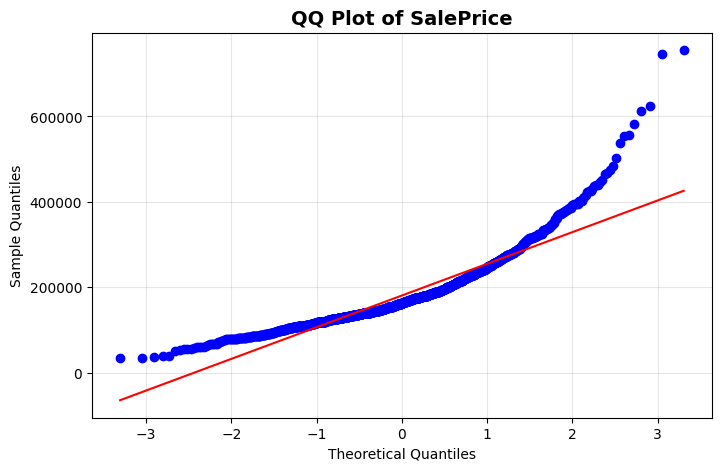

In [17]:
import matplotlib.pyplot as plt
import scipy.stats as stats

target_col = "SalePrice"
target_series = train_df[target_col].dropna()

plt.figure(figsize=(8, 5))
stats.probplot(target_series, dist="norm", plot=plt)
plt.title("QQ Plot of SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(alpha=0.3)
plt.show()

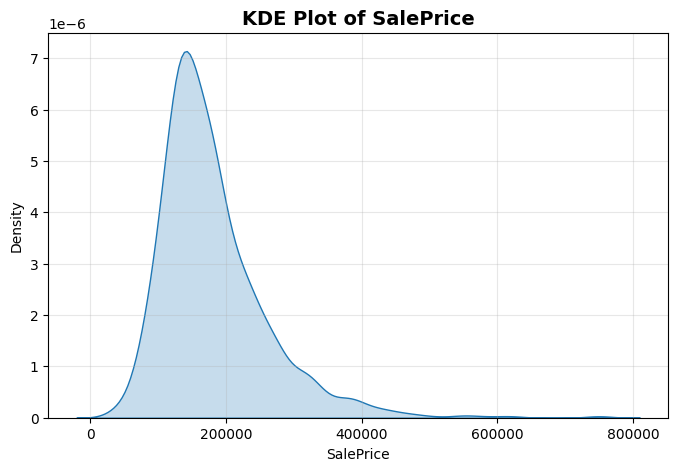

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "SalePrice"
target_series = train_df[target_col].dropna()

plt.figure(figsize=(8, 5))
sns.kdeplot(target_series, fill=True)
plt.title("KDE Plot of SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("SalePrice")
plt.ylabel("Density")
plt.grid(alpha=0.3)
plt.show()

`SalePrice` has no missing values, but its distribution is highly right-skewed with a long right tail, meaning most houses are in the lower-to-mid price range while a few expensive houses act as extreme values.
The QQ plot and high kurtosis confirm that the target is not normally distributed, so applying log transformation on `SalePrice` can be useful before modeling.

For `SalePrice`, we can use **log transformation** because the target is highly right-skewed and has a long right tail.
The best practical option is `np.log1p(SalePrice)`, because it handles positive values safely and usually makes house price distribution closer to normal.

## 2.2 Target Outlier Analysis

In this section, we will detect outliers in the target feature `SalePrice` using the IQR method.
We will check the outlier count, outlier percentage, lower and upper bounds, and inspect the extreme values visually using box-based plots.

In [19]:
import pandas as pd
import numpy as np

target_col = "SalePrice"
target_series = train_df[target_col].dropna()

# IQR method
q1 = target_series.quantile(0.25)
q3 = target_series.quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Outliers
outlier_mask = (target_series < lower_bound) | (target_series > upper_bound)
outliers = target_series[outlier_mask]

# Extreme values
lower_outliers = target_series[target_series < lower_bound].sort_values()
upper_outliers = target_series[target_series > upper_bound].sort_values(ascending=False)

target_outlier_summary = ({
    "target_column": [target_col],
    "method": ["IQR"],
    "q1": [round(q1, 2)],
    "q3": [round(q3, 2)],
    "iqr": [round(iqr, 2)],
    "lower_bound": [round(lower_bound, 2)],
    "upper_bound": [round(upper_bound, 2)],
    "outlier_count": [outliers.shape[0]],
    "outlier_percentage": [round((outliers.shape[0] / len(target_series)) * 100, 2)],
    "lower_outlier_count": [lower_outliers.shape[0]],
    "upper_outlier_count": [upper_outliers.shape[0]],
    "min_outlier_value": [outliers.min() if len(outliers) > 0 else None],
    "max_outlier_value": [outliers.max() if len(outliers) > 0 else None]
})

target_outlier_summary

{'target_column': ['SalePrice'],
 'method': ['IQR'],
 'q1': [np.float64(129975.0)],
 'q3': [np.float64(214000.0)],
 'iqr': [np.float64(84025.0)],
 'lower_bound': [np.float64(3937.5)],
 'upper_bound': [np.float64(340037.5)],
 'outlier_count': [61],
 'outlier_percentage': [4.18],
 'lower_outlier_count': [0],
 'upper_outlier_count': [61],
 'min_outlier_value': [np.int64(341000)],
 'max_outlier_value': [np.int64(755000)]}

In [20]:
target_outlier_summary_df = pd.DataFrame(target_outlier_summary)
target_outlier_summary_df

,target_column,method,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage,lower_outlier_count,upper_outlier_count,min_outlier_value,max_outlier_value
0,SalePrice,IQR,129975.0,214000.0,84025.0,3937.5,340037.5,61,4.18,0,61,341000,755000


In [21]:
# Top 10 highest extreme values
top_upper_extreme_values = upper_outliers.head(10).reset_index()
top_upper_extreme_values.columns = ["index", "SalePrice"]

top_upper_extreme_values

,index,SalePrice
0,691,755000
1,1182,745000
2,1169,625000
3,898,611657
4,803,582933
5,1046,556581
6,440,555000
7,769,538000
8,178,501837
9,798,485000


In [22]:
# Top 10 lowest extreme values (if any)
top_lower_extreme_values = lower_outliers.head(10).reset_index()
top_lower_extreme_values.columns = ["index", "SalePrice"]

top_lower_extreme_values

,index,SalePrice


> there is no 🤡🤡

### Box and Boxen Plot

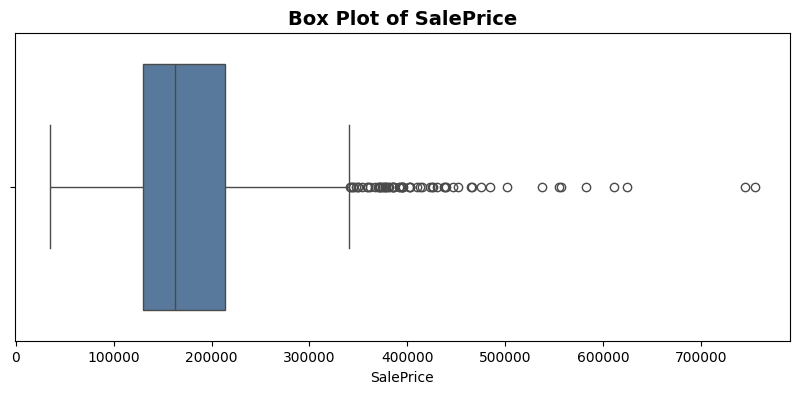

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.boxplot(x=train_df[target_col], color="#4E79A7")
plt.title("Box Plot of SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("SalePrice")
plt.show()

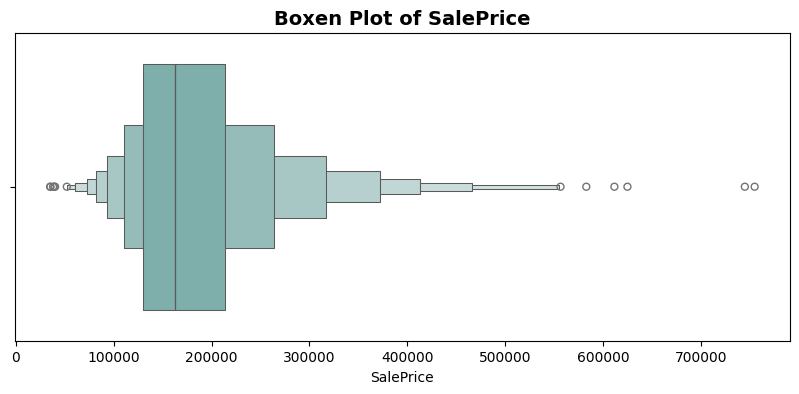

In [24]:
plt.figure(figsize=(10, 4))
sns.boxenplot(x=train_df[target_col], color="#76B7B2")
plt.title("Boxen Plot of SalePrice", fontsize=14, fontweight="bold")
plt.xlabel("SalePrice")
plt.show()

`SalePrice` contains **61 outliers**, which is about **4.18%** of the dataset, and all outliers are on the upper side above the IQR upper bound of **340,037.5**.
There are no lower-side outliers, but extreme high prices range from **341,000 to 755,000**, so these high-value houses should be handled carefully instead of removing blindly.

## 2.3 Target Percentile Analysis

In this section, we will check important percentile points of `SalePrice` to understand the lower range, middle range, and extreme high-price range.
This helps us identify how prices are distributed across different parts of the target variable.

In [25]:
target_col = "SalePrice"
target_series = train_df[target_col].dropna()

percentile_points = {
    "P01": 0.01,
    "P05": 0.05,
    "P25": 0.25,
    "P50": 0.50,
    "P75": 0.75,
    "P95": 0.95,
    "P99": 0.99
}

target_percentiles = pd.DataFrame({
    "percentile": list(percentile_points.keys()),
    "value": [
        round(target_series.quantile(q), 2)
        for q in percentile_points.values()
    ]
})

target_percentiles

,percentile,value
0,P01,61815.97
1,P05,88000.00
2,P25,129975.00
3,P50,163000.00
4,P75,214000.00
5,P95,326100.00
6,P99,442567.01


In [26]:
for p_name, q in percentile_points.items():
    target_summary_df[p_name] = round(target_series.quantile(q), 2)

target_summary_df

,target_column,feature_type,dtype,missing_count,missing_percentage,min,max,mean,median,mode,std,variance,range,P01,P05,P25,P50,P75,P95,P99
0,SalePrice,target,int64,0,0.0,34900,755000,180921.2,163000.0,140000,79442.5,6.311111e+09,720100,61815.97,88000.0,129975.0,163000.0,214000.0,326100.0,442567.01


### Histogram + KDE with Percentile Lines

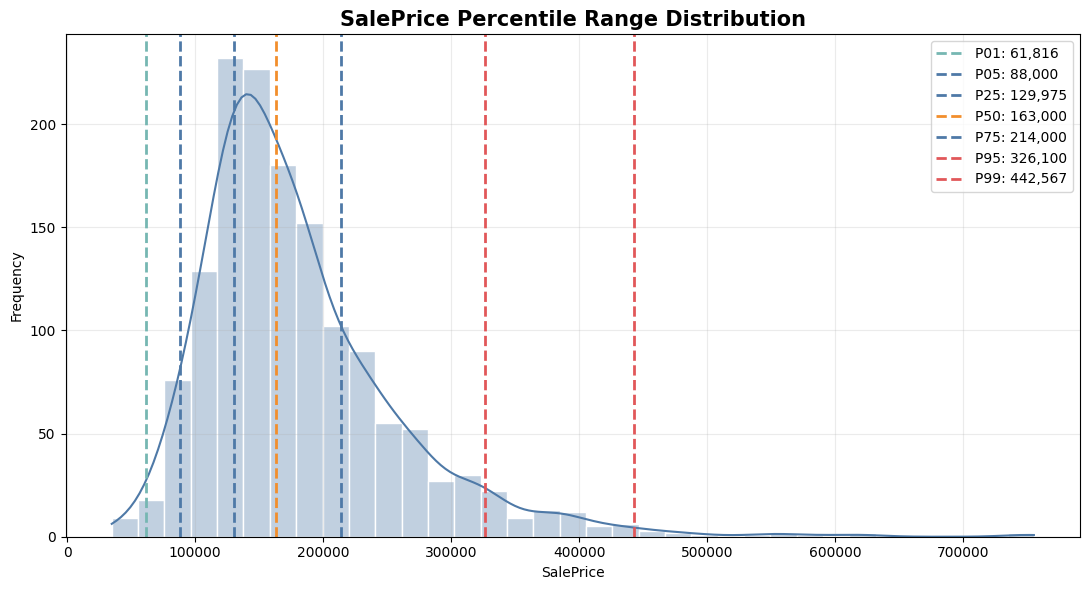

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

percentile_values = {
    p_name: target_series.quantile(q)
    for p_name, q in percentile_points.items()
}

colors = {
    "P01": "#76B7B2",
    "P05": "#4E79A7",
    "P25": "#4E79A7",
    "P50": "#F28E2C",
    "P75": "#4E79A7",
    "P95": "#E15759",
    "P99": "#E15759"
}

plt.figure(figsize=(11, 6))

sns.histplot(
    target_series,
    bins=35,
    kde=True,
    color="#4E79A7",
    alpha=0.35,
    edgecolor="white"
)

for p_name, value in percentile_values.items():
    plt.axvline(
        value,
        color=colors[p_name],
        linestyle="--",
        linewidth=2,
        label=f"{p_name}: {value:,.0f}"
    )

plt.title("SalePrice Percentile Range Distribution", fontsize=15, fontweight="bold")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### hightlighted zone

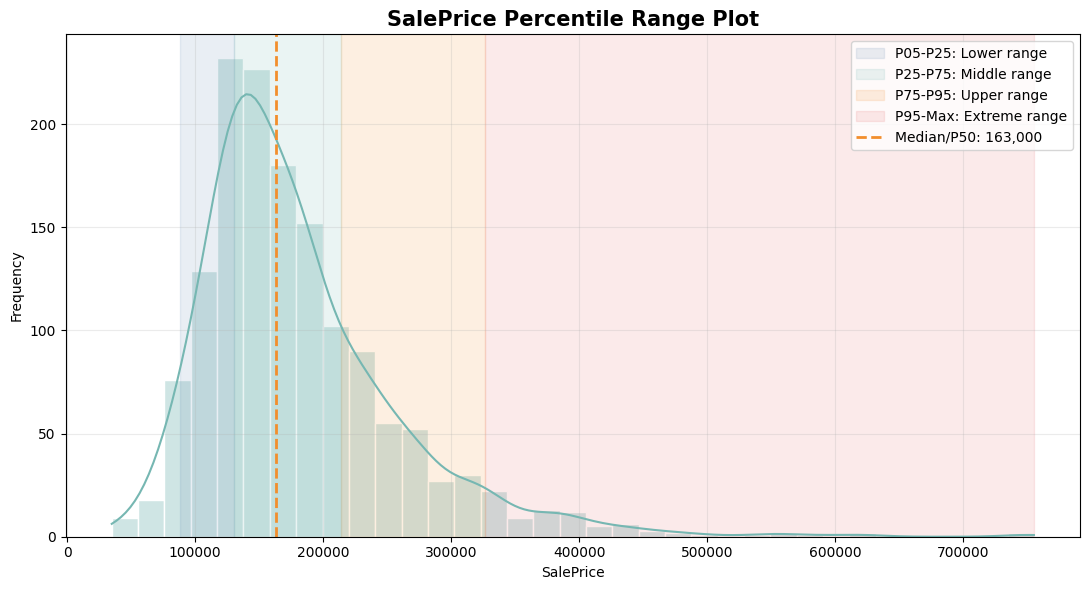

In [28]:
p05 = target_series.quantile(0.05)
p25 = target_series.quantile(0.25)
p50 = target_series.quantile(0.50)
p75 = target_series.quantile(0.75)
p95 = target_series.quantile(0.95)

plt.figure(figsize=(11, 6))

sns.histplot(
    target_series,
    bins=35,
    kde=True,
    color="#76B7B2",
    alpha=0.35,
    edgecolor="white"
)

plt.axvspan(p05, p25, color="#4E79A7", alpha=0.12, label="P05-P25: Lower range")
plt.axvspan(p25, p75, color="#76B7B2", alpha=0.15, label="P25-P75: Middle range")
plt.axvspan(p75, p95, color="#F28E2C", alpha=0.14, label="P75-P95: Upper range")
plt.axvspan(p95, target_series.max(), color="#E15759", alpha=0.12, label="P95-Max: Extreme range")

plt.axvline(p50, color="#F28E2C", linestyle="--", linewidth=2, label=f"Median/P50: {p50:,.0f}")

plt.title("SalePrice Percentile Range Plot", fontsize=15, fontweight="bold")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

`SalePrice` distribution shows that most houses are concentrated between **P25 = 129,975** and **P75 = 214,000**, with the median price around **163,000**.
Prices above **P95 = 326,100** and especially above **P99 = 442,567** represent the extreme high-end range, confirming the long right tail in the target distribution.

## 2.4 Target Trend Over Time

In this section, we will analyze how the target column `SalePrice` changes over time using `YrSold` and `MoSold`.
This helps us understand whether house prices show any increasing, decreasing, or seasonal trend across sale periods.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

target_col = "SalePrice"

# Create temporary dataframe
target_time_df = train_df[["YrSold", "MoSold", target_col]].copy()

# Create sale date from year and month
target_time_df["SaleDate"] = pd.to_datetime(
    dict(
        year=target_time_df["YrSold"],
        month=target_time_df["MoSold"],
        day=1
    )
)

# Monthly trend summary
monthly_target_trend = (
    target_time_df
    .groupby("SaleDate")
    .agg(
        mean_sale_price=(target_col, "mean"),
        median_sale_price=(target_col, "median"),
        sale_count=(target_col, "count")
    )
    .reset_index()
)

monthly_target_trend.head()

,SaleDate,mean_sale_price,median_sale_price,sale_count
0,2006-01-01,201090.000000,176700.0,10
1,2006-02-01,194322.222222,192500.0,9
2,2006-03-01,184982.200000,162900.0,25
3,2006-04-01,174312.814815,145250.0,27
4,2006-05-01,158928.289474,156950.0,38


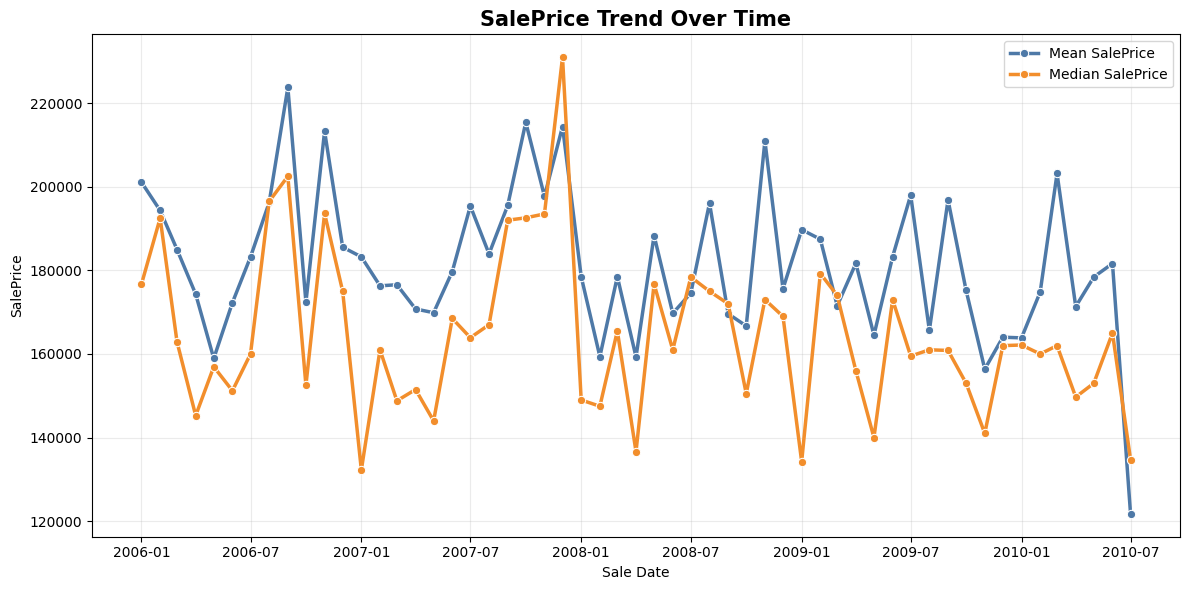

In [30]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_target_trend,
    x="SaleDate",
    y="mean_sale_price",
    marker="o",
    linewidth=2.5,
    color="#4E79A7",
    label="Mean SalePrice"
)

sns.lineplot(
    data=monthly_target_trend,
    x="SaleDate",
    y="median_sale_price",
    marker="o",
    linewidth=2.5,
    color="#F28E2C",
    label="Median SalePrice"
)

plt.title("SalePrice Trend Over Time", fontsize=15, fontweight="bold")
plt.xlabel("Sale Date")
plt.ylabel("SalePrice")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
yearly_target_trend = (
    train_df
    .groupby("YrSold")
    .agg(
        mean_sale_price=(target_col, "mean"),
        median_sale_price=(target_col, "median"),
        sale_count=(target_col, "count")
    )
    .reset_index()
)

yearly_target_trend

,YrSold,mean_sale_price,median_sale_price,sale_count
0,2006,182549.458599,163995.0,314
1,2007,186063.151976,167000.0,329
2,2008,177360.838816,164000.0,304
3,2009,179432.103550,162000.0,338
4,2010,177393.674286,155000.0,175


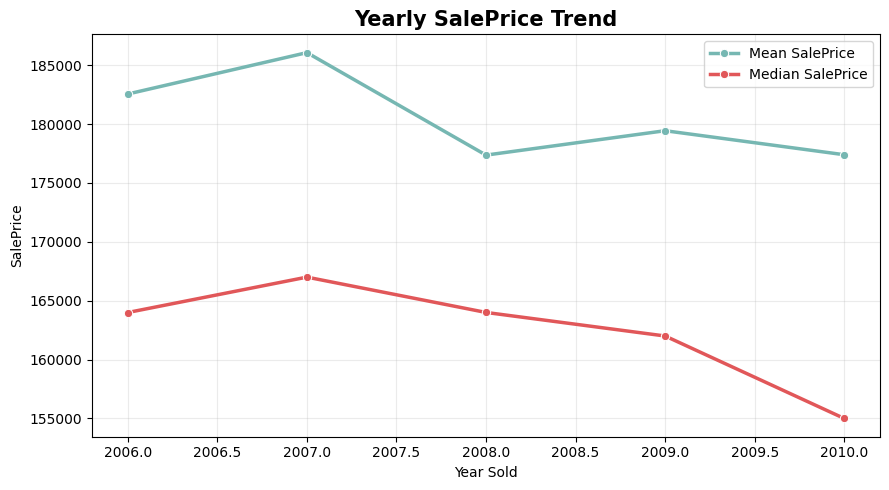

In [32]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    data=yearly_target_trend,
    x="YrSold",
    y="mean_sale_price",
    marker="o",
    linewidth=2.5,
    color="#76B7B2",
    label="Mean SalePrice"
)

sns.lineplot(
    data=yearly_target_trend,
    x="YrSold",
    y="median_sale_price",
    marker="o",
    linewidth=2.5,
    color="#E15759",
    label="Median SalePrice"
)

plt.title("Yearly SalePrice Trend", fontsize=15, fontweight="bold")
plt.xlabel("Year Sold")
plt.ylabel("SalePrice")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

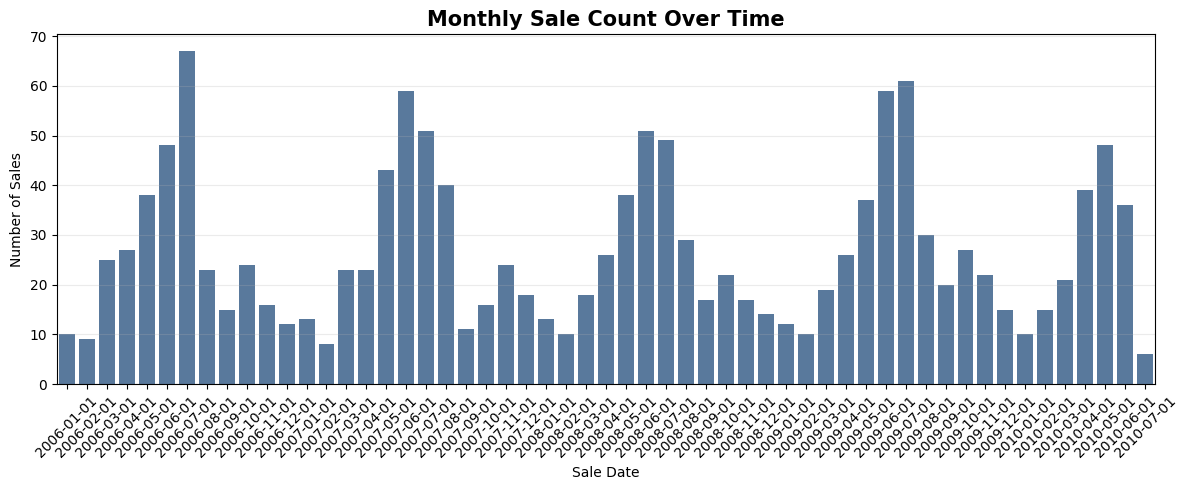

In [33]:
plt.figure(figsize=(12, 5))

sns.barplot(
    data=monthly_target_trend,
    x="SaleDate",
    y="sale_count",
    color="#4E79A7"
)

plt.title("Monthly Sale Count Over Time", fontsize=15, fontweight="bold")
plt.xlabel("Sale Date")
plt.ylabel("Number of Sales")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Mid-year months show higher house sale activity, while winter months show lower sale activity. This suggests a possible seasonal pattern in house buying behavior.

`SalePrice` over time does not show a strong continuous upward or downward trend; the monthly trend fluctuates noticeably across different sale periods.
Yearly average and median prices were slightly higher around **2007**, then declined after **2008**, with the lowest median appearing around **2010**.
Monthly sale count shows some seasonality, where sales are generally higher around spring to early summer months and lower near year-end.
Overall, `YrSold` and `MoSold` may contain some seasonal/time-related signal, but they should be treated as supporting features rather than strong predictors.

## 2.5 Target Transformation Check

Since `SalePrice` is highly right-skewed and heavy-tailed, we will compare the original target with a log-transformed version using `np.log1p()`.
This helps us check whether log transformation can make the target distribution more normal and model-friendly.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

target_col = "SalePrice"

# Original and log-transformed target
original_target = train_df[target_col].dropna()
log_target = np.log1p(original_target)

# Skewness and kurtosis comparison
target_transform_comparison = pd.DataFrame({
    "target_version": ["Original SalePrice", "Log1p SalePrice"],
    "mean": [round(original_target.mean(), 3), round(log_target.mean(), 3)],
    "median": [round(original_target.median(), 3), round(log_target.median(), 3)],
    "std": [round(original_target.std(), 3), round(log_target.std(), 3)],
    "skewness": [round(original_target.skew(), 3), round(log_target.skew(), 3)],
    "kurtosis": [round(original_target.kurt(), 3), round(log_target.kurt(), 3)]
})

target_transform_comparison

,target_version,mean,median,std,skewness,kurtosis
0,Original SalePrice,180921.196,163000.000,79442.503,1.883,6.536
1,Log1p SalePrice,12.024,12.002,0.399,0.121,0.810


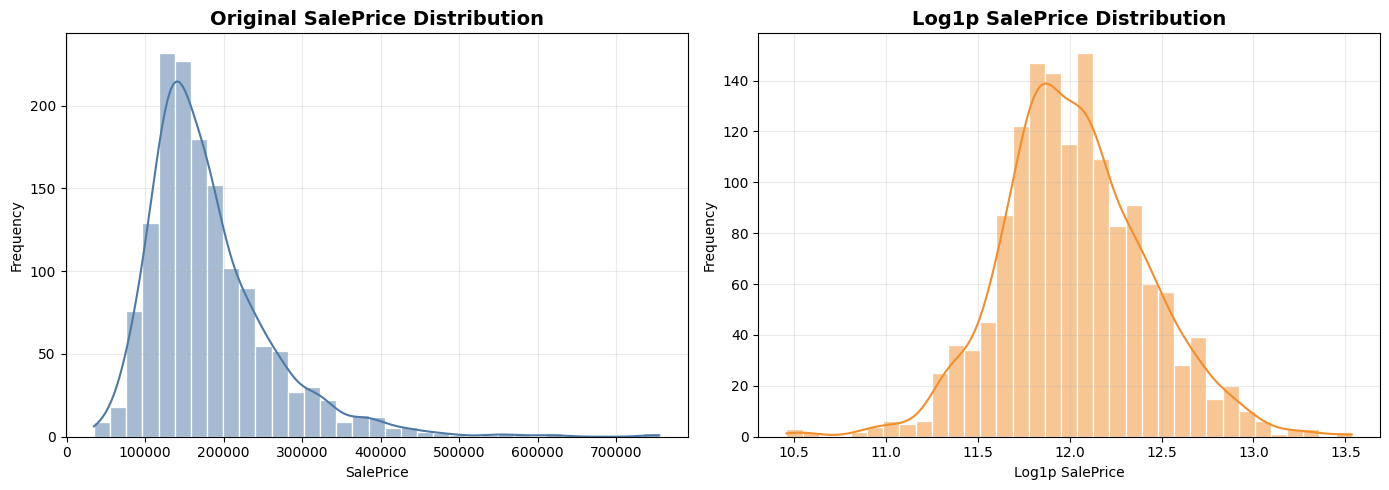

In [35]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.histplot(original_target, kde=True, bins=35, color="#4E79A7", edgecolor="white")
plt.title("Original SalePrice Distribution", fontsize=14, fontweight="bold")
plt.xlabel("SalePrice")
plt.ylabel("Frequency")
plt.grid(alpha=0.25)

plt.subplot(1, 2, 2)
sns.histplot(log_target, kde=True, bins=35, color="#F28E2C", edgecolor="white")
plt.title("Log1p SalePrice Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Log1p SalePrice")
plt.ylabel("Frequency")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

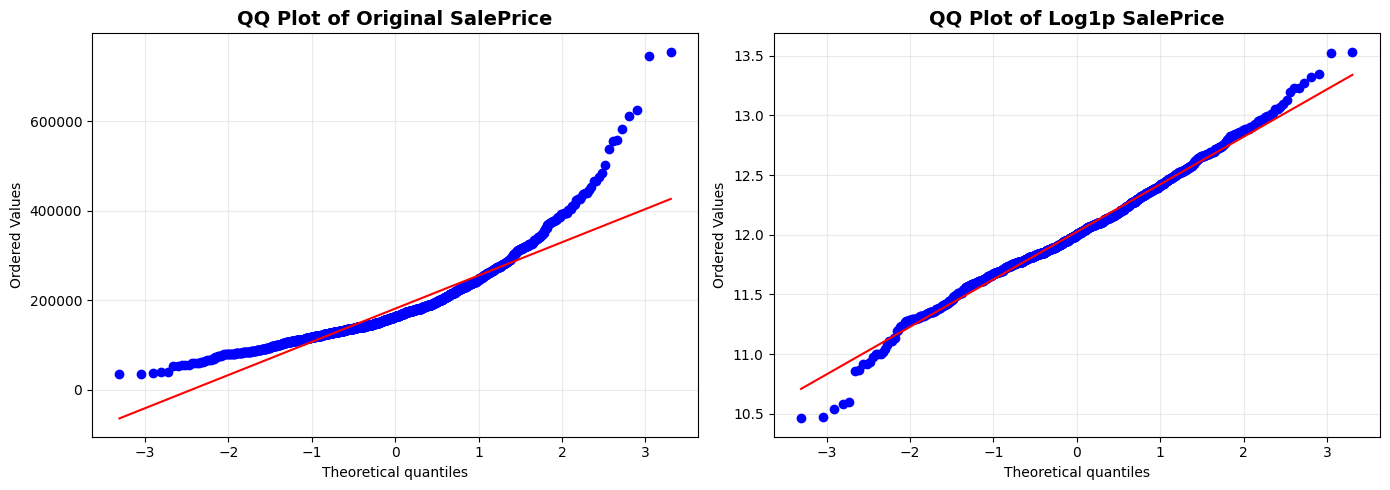

In [36]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
stats.probplot(original_target, dist="norm", plot=plt)
plt.title("QQ Plot of Original SalePrice", fontsize=14, fontweight="bold")
plt.grid(alpha=0.25)

plt.subplot(1, 2, 2)
stats.probplot(log_target, dist="norm", plot=plt)
plt.title("QQ Plot of Log1p SalePrice", fontsize=14, fontweight="bold")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Log transformation should be checked because the original `SalePrice` is highly right-skewed and heavy-tailed.
If `log1p(SalePrice)` reduces skewness and improves the QQ plot pattern, it can be used as a more model-friendly target.

In [37]:
target_summary_df

,target_column,feature_type,dtype,missing_count,missing_percentage,min,max,mean,median,mode,std,variance,range,P01,P05,P25,P50,P75,P95,P99
0,SalePrice,target,int64,0,0.0,34900,755000,180921.2,163000.0,140000,79442.5,6.311111e+09,720100,61815.97,88000.0,129975.0,163000.0,214000.0,326100.0,442567.01


In [38]:
import pandas as pd

def make_one_row_report(obj, prefix=None):

    if isinstance(obj, dict):
        obj = pd.DataFrame(obj)

    temp = obj.copy()

    # Percentile report: columns = percentile, value
    if {"percentile", "value"}.issubset(temp.columns):
        temp = temp.set_index("percentile")["value"].to_frame().T

    # Log transform comparison report: target_version wise pivot
    elif "target_version" in temp.columns:
        temp = temp.set_index("target_version")
        temp.index = (
            temp.index
            .str.lower()
            .str.replace(" ", "_")
            .str.replace("saleprice", "saleprice", regex=False)
        )

        temp = temp.stack().to_frame().T
        temp.columns = [f"{idx}_{col}" for idx, col in temp.columns]

    # Normal one-row report
    elif temp.shape[0] == 1:
        temp = temp.reset_index(drop=True)

    # Prefix add
    if prefix:
        temp = temp.add_prefix(prefix)

    return temp.reset_index(drop=True)

In [39]:
reports_to_add = []

# 1. Basic target summary
reports_to_add.append(
    make_one_row_report(target_summary)
)

# 2. Percentile summary
reports_to_add.append(
    make_one_row_report(target_percentiles)
)

# 3. Outlier summary
reports_to_add.append(
    make_one_row_report(target_outlier_summary)
)

# 4. Log transform comparison
reports_to_add.append(
    make_one_row_report(target_transform_comparison)
)

# 5. High-price row summary
if "high_price_summary" in globals():
    reports_to_add.append(
        make_one_row_report(high_price_summary)
    )

# Final combined target summary
target_summary_df = pd.concat(reports_to_add, axis=1)

target_summary_df

,target_column,feature_type,dtype,missing_count,missing_percentage,min,max,mean,median,mode,std,variance,range,skewness,kurtosis,skewness_shape,kurtosis_shape,distribution_shape,P01,P05,P25,P50,P75,P95,P99,target_column,method,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage,lower_outlier_count,upper_outlier_count,min_outlier_value,max_outlier_value,original_saleprice_mean,original_saleprice_median,original_saleprice_std,original_saleprice_skewness,original_saleprice_kurtosis,log1p_saleprice_mean,log1p_saleprice_median,log1p_saleprice_std,log1p_saleprice_skewness,log1p_saleprice_kurtosis
0,SalePrice,target,int64,0,0.0,34900,755000,180921.2,163000.0,140000,79442.5,6.311111e+09,720100,1.883,6.536,highly right-skewed,leptokurtic / heavy-tailed,highly right-skewed and leptokurtic / heavy-ta...,61815.97,88000.0,129975.0,163000.0,214000.0,326100.0,442567.01,SalePrice,IQR,129975.0,214000.0,84025.0,3937.5,340037.5,61,4.18,0,61,341000,755000,180921.196,163000.0,79442.503,1.883,6.536,12.024,12.002,0.399,0.121,0.81


## 3. Numerical Feature Analysis

In this section, we will analyze the numerical features to understand their distribution, missing values, outliers, and relationship with the target variable `SalePrice`.
This step helps identify important numerical patterns before feature engineering and model building.

### 3.1 Basic Checking

First, we will check the basic structure of numerical features, data types, and summary statistics.
This will give us an initial understanding of the numerical feature quality before deeper analysis.

In [40]:
numeric_df = house_column_summary.loc[
    house_column_summary["auto_detected_type"] == "numeric",
    ["column", "pandas_dtype", "auto_detected_type", "final_corrected_type"]
].reset_index(drop=True)

numeric_df

,column,pandas_dtype,auto_detected_type,final_corrected_type
0,Id,int64,numeric,id_like
1,MSSubClass,int64,numeric,categorical
2,LotFrontage,float64,numeric,numeric
3,LotArea,int64,numeric,numeric
4,OverallQual,int64,numeric,categorical
5,OverallCond,int64,numeric,categorical
6,YearBuilt,int64,numeric,year_like
7,YearRemodAdd,int64,numeric,year_like
8,MasVnrArea,float64,numeric,numeric
9,BsmtFinSF1,int64,numeric,numeric


From these auto-detected numeric features, **1 column is ID-like**: `Id`; **4 columns are year-like**: `YearBuilt`, `YearRemodAdd`, `GarageYrBlt`, `YrSold`; **1 column is month-like**: `MoSold`; and **3 columns are categorical/ordinal categorical**: `MSSubClass`, `OverallQual`, `OverallCond`.
So, not all auto-detected numeric columns should be treated as pure numerical features; some need manual correction based on their actual meaning.

> pandas detected numeric columns count: 38 
> pure numeric columns count:28


#### Auto-detected numeric base DataFrame

In [41]:
auto_numeric_df = (
    house_column_summary
    .loc[
        house_column_summary["auto_detected_type"] == "numeric",
        ["column", "pandas_dtype", "auto_detected_type", "final_corrected_type"]
    ]
    .rename(columns={
        "column": "column_name",
        "final_corrected_type": "manual_type"
    })
    .reset_index(drop=True)
)

auto_numeric_df

,column_name,pandas_dtype,auto_detected_type,manual_type
0,Id,int64,numeric,id_like
1,MSSubClass,int64,numeric,categorical
2,LotFrontage,float64,numeric,numeric
3,LotArea,int64,numeric,numeric
4,OverallQual,int64,numeric,categorical
5,OverallCond,int64,numeric,categorical
6,YearBuilt,int64,numeric,year_like
7,YearRemodAdd,int64,numeric,year_like
8,MasVnrArea,float64,numeric,numeric
9,BsmtFinSF1,int64,numeric,numeric


#### Numeric dtype add

In [42]:
def get_numeric_dtype(dtype):
    dtype = str(dtype)

    if "int" in dtype:
        return "int"
    elif "float" in dtype:
        return "float"
    elif "Int" in dtype or "Float" in dtype:
        return "nullable numeric"
    else:
        return "numeric"

auto_numeric_df["numeric_dtype"] = auto_numeric_df["pandas_dtype"].apply(get_numeric_dtype)

auto_numeric_df.head()

,column_name,pandas_dtype,auto_detected_type,manual_type,numeric_dtype
0,Id,int64,numeric,id_like,int
1,MSSubClass,int64,numeric,categorical,int
2,LotFrontage,float64,numeric,numeric,float
3,LotArea,int64,numeric,numeric,int
4,OverallQual,int64,numeric,categorical,int


#### Primary type add

In [43]:
def get_primary_type(row):
    col = row["column_name"]
    manual_type = row["manual_type"]

    if manual_type == "id_like":
        return "numeric-code"
    elif manual_type == "target":
        return "target"
    elif manual_type == "year_like":
        return "year-like"
    elif manual_type == "month_like":
        return "month-like"
    elif manual_type == "categorical":
        return "ordinal / numeric-category"
    elif manual_type == "numeric":
        unique_count = train_df[col].nunique(dropna=True)

        if unique_count == 2:
            return "binary"
        elif pd.api.types.is_integer_dtype(train_df[col]) and unique_count <= 30:
            return "count"
        else:
            return "continuous"

    return manual_type

auto_numeric_df["primary_type"] = auto_numeric_df.apply(get_primary_type, axis=1)

auto_numeric_df

,column_name,pandas_dtype,auto_detected_type,manual_type,numeric_dtype,primary_type
0,Id,int64,numeric,id_like,int,numeric-code
1,MSSubClass,int64,numeric,categorical,int,ordinal / numeric-category
2,LotFrontage,float64,numeric,numeric,float,continuous
3,LotArea,int64,numeric,numeric,int,continuous
4,OverallQual,int64,numeric,categorical,int,ordinal / numeric-category
5,OverallCond,int64,numeric,categorical,int,ordinal / numeric-category
6,YearBuilt,int64,numeric,year_like,int,year-like
7,YearRemodAdd,int64,numeric,year_like,int,year-like
8,MasVnrArea,float64,numeric,numeric,float,continuous
9,BsmtFinSF1,int64,numeric,numeric,int,continuous


#### Detection confidence add

In [44]:
def get_detection_confidence(row):
    auto_type = row["auto_detected_type"]
    manual_type = row["manual_type"]

    if auto_type == manual_type:
        return "high"
    elif manual_type in ["numeric", "target"]:
        return "high"
    elif manual_type in ["year_like", "month_like", "categorical", "id_like"]:
        return "manual correction needed"
    else:
        return "medium"

auto_numeric_df["detection_confidence"] = auto_numeric_df.apply(get_detection_confidence, axis=1)

auto_numeric_df

,column_name,pandas_dtype,auto_detected_type,manual_type,numeric_dtype,primary_type,detection_confidence
0,Id,int64,numeric,id_like,int,numeric-code,manual correction needed
1,MSSubClass,int64,numeric,categorical,int,ordinal / numeric-category,manual correction needed
2,LotFrontage,float64,numeric,numeric,float,continuous,high
3,LotArea,int64,numeric,numeric,int,continuous,high
4,OverallQual,int64,numeric,categorical,int,ordinal / numeric-category,manual correction needed
5,OverallCond,int64,numeric,categorical,int,ordinal / numeric-category,manual correction needed
6,YearBuilt,int64,numeric,year_like,int,year-like,manual correction needed
7,YearRemodAdd,int64,numeric,year_like,int,year-like,manual correction needed
8,MasVnrArea,float64,numeric,numeric,float,continuous,high
9,BsmtFinSF1,int64,numeric,numeric,int,continuous,high


#### Final ordered DataFrame

In [45]:
auto_numeric_df = auto_numeric_df[
    [
        "column_name",
        "pandas_dtype",
        "numeric_dtype",
        "auto_detected_type",
        "primary_type",
        "manual_type",
        "detection_confidence"
    ]
]

auto_numeric_df

,column_name,pandas_dtype,numeric_dtype,auto_detected_type,primary_type,manual_type,detection_confidence
0,Id,int64,int,numeric,numeric-code,id_like,manual correction needed
1,MSSubClass,int64,int,numeric,ordinal / numeric-category,categorical,manual correction needed
2,LotFrontage,float64,float,numeric,continuous,numeric,high
3,LotArea,int64,int,numeric,continuous,numeric,high
4,OverallQual,int64,int,numeric,ordinal / numeric-category,categorical,manual correction needed
5,OverallCond,int64,int,numeric,ordinal / numeric-category,categorical,manual correction needed
6,YearBuilt,int64,int,numeric,year-like,year_like,manual correction needed
7,YearRemodAdd,int64,int,numeric,year-like,year_like,manual correction needed
8,MasVnrArea,float64,float,numeric,continuous,numeric,high
9,BsmtFinSF1,int64,int,numeric,continuous,numeric,high


#### Column list and count

In [46]:
auto_numeric_cols = auto_numeric_df["column_name"].tolist()

print(f"Total auto-detected numeric columns: {len(auto_numeric_cols)}")
auto_numeric_cols

Total auto-detected numeric columns: 38


['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

#### Type summary

In [47]:
auto_numeric_type_summary = (
    auto_numeric_df
    .groupby(["primary_type", "manual_type"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

auto_numeric_type_summary

,primary_type,manual_type,count
0,continuous,numeric,15
1,count,numeric,13
6,year-like,year_like,4
4,ordinal / numeric-category,categorical,3
2,month-like,month_like,1
3,numeric-code,id_like,1
5,target,target,1


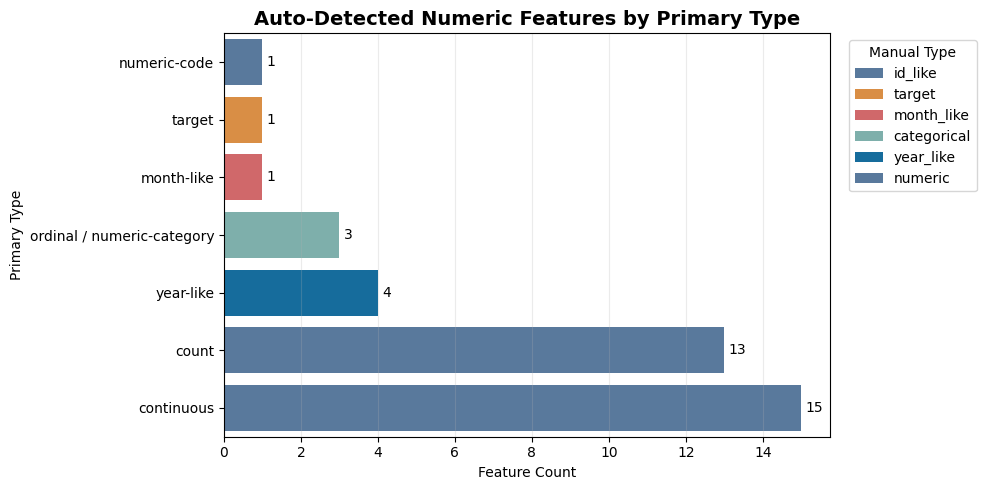

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = auto_numeric_type_summary.sort_values("count", ascending=True)

plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=plot_df,
    x="count",
    y="primary_type",
    hue="manual_type",
    palette=["#4E79A7", "#F28E2C", "#E15759", "#76B7B2", "#0072B2"]
)

plt.title("Auto-Detected Numeric Features by Primary Type", fontsize=14, fontweight="bold")
plt.xlabel("Feature Count")
plt.ylabel("Primary Type")

# Add count labels
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.grid(axis="x", alpha=0.25)
plt.legend(title="Manual Type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

Among the auto-detected numeric features, most columns are true numerical features: **15 continuous** and **13 count-based** columns, while the remaining numeric-looking columns are year-like, month-like, ID-like, target, or ordinal categorical features.
**Continuous features** represent measurable values with many possible ranges, such as area or frontage, while **count features** represent discrete quantities, such as number of rooms, bathrooms, fireplaces, or garage cars.

### count plot for count features

In [49]:
count_cols = auto_numeric_df.loc[
    auto_numeric_df["primary_type"] == "count",
    "column_name"
].tolist()

print(f"Total count features: {len(count_cols)}")
count_cols

Total count features: 13


['LowQualFinSF',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 '3SsnPorch',
 'PoolArea',
 'MiscVal']

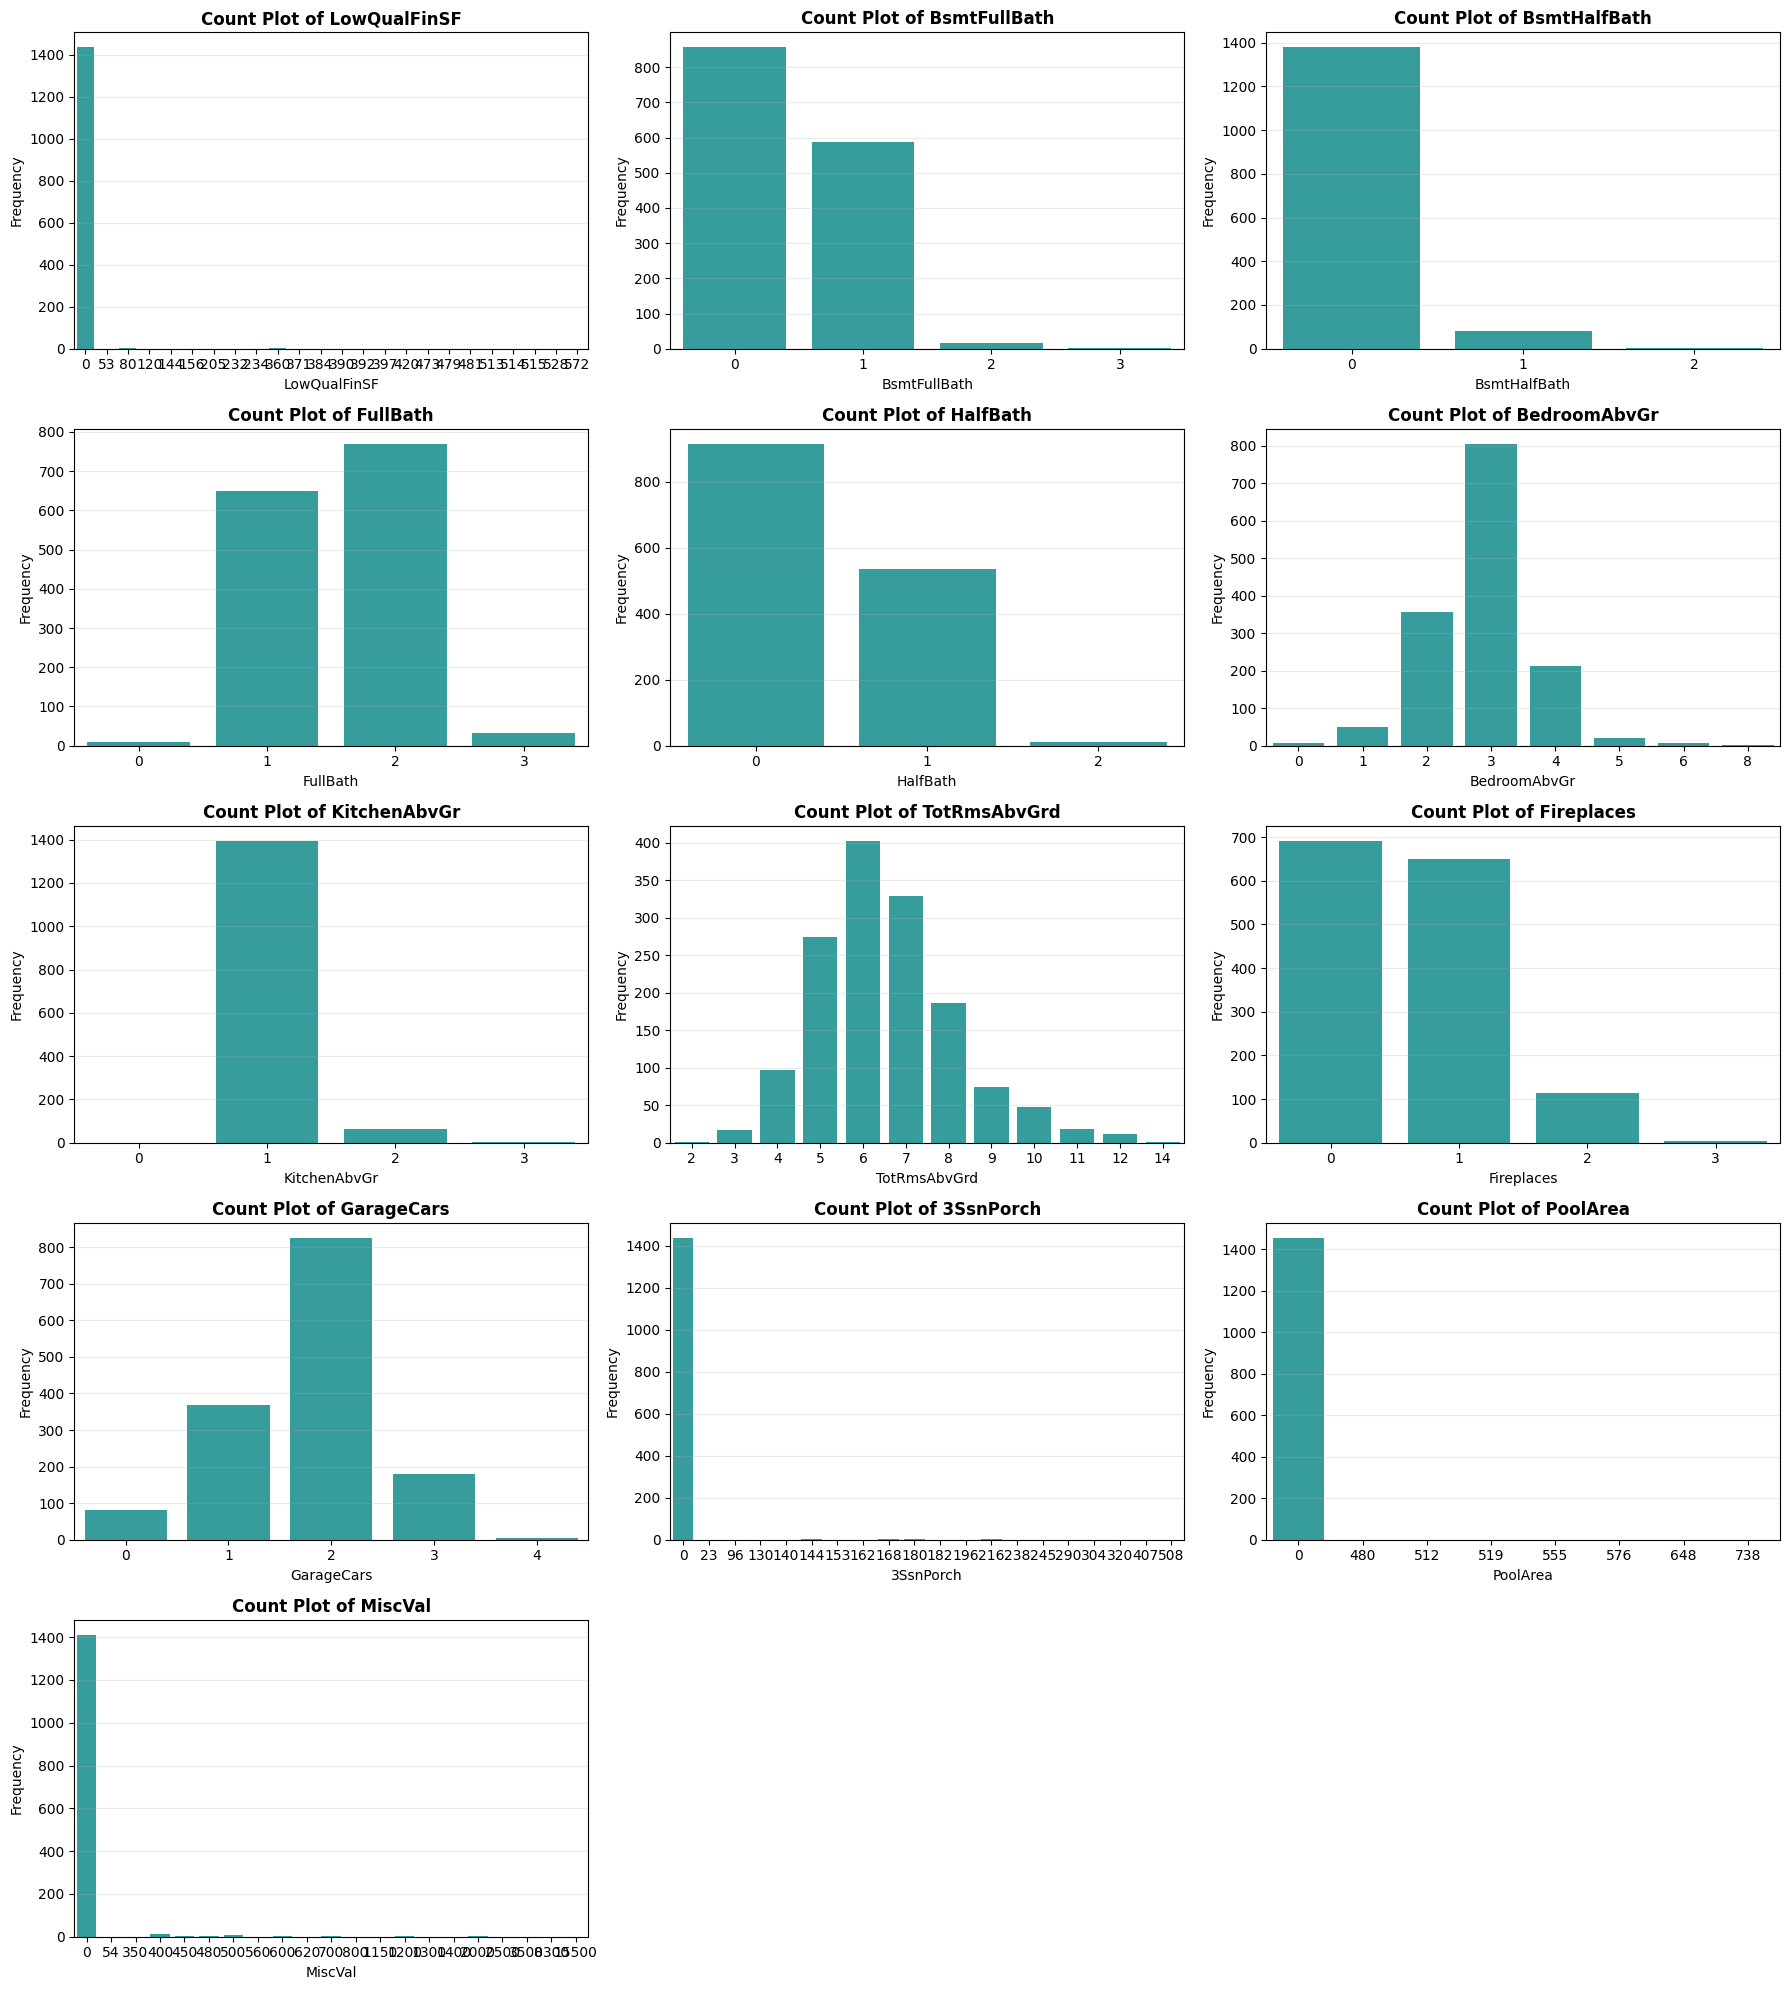

In [50]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

count_cols = auto_numeric_df.loc[
    auto_numeric_df["primary_type"] == "count",
    "column_name"
].tolist()

n_cols = 3
n_rows = math.ceil(len(count_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    order = sorted(train_df[col].dropna().unique())

    sns.countplot(
        data=train_df,
        x=col,
        order=order,
        ax=axes[i],
        color="#26ADAD"
    )

    axes[i].set_title(f"Count Plot of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(axis="y", alpha=0.25)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- `MiscVal`: Highly zero-inflated; most houses have no miscellaneous value, so create a binary feature like `HasMiscVal` and treat the raw value carefully.
- `KitchenAbvGr`: Mostly value `1`; keep as a discrete count feature, while rare values like `2` or `3` may indicate unusual/multi-unit houses.
- `TotRmsAbvGrd`: Reasonably distributed around common room counts; keep as an important discrete count feature.
- `Fireplaces`: Mostly `0` or `1`; keep as a count feature and optionally create `HasFireplace`.
- `GarageCars`: Mostly `1` or `2`; keep as a strong count feature because garage capacity likely relates to house price.
- `3SsnPorch`: Highly zero-inflated; better treated as a zero-heavy area feature, with optional binary feature `Has3SsnPorch`.
- `PoolArea`: Almost all values are `0`; create `HasPool` and avoid relying only on raw `PoolArea`.
- `LowQualFinSF`: Almost all values are `0`; create `HasLowQualFinSF` or keep carefully as a zero-inflated area feature.
- `BsmtFullBath`: Mostly `0` or `1`; keep as a meaningful basement bathroom count feature.
- `BsmtHalfBath`: Mostly `0`; likely weak alone, but can be kept or converted into `HasBsmtHalfBath`.
- `FullBath`: Mostly `1` or `2`; keep as an important bathroom count feature.
- `HalfBath`: Mostly `0` or `1`; keep as a discrete count feature.
- `BedroomAbvGr`: Mostly `2`, `3`, or `4`; keep as a meaningful bedroom count feature, while rare high values should be checked.

In [51]:
continuous_numeric_cols = auto_numeric_df.loc[
    auto_numeric_df["primary_type"] == "continuous",
    "column_name"
].tolist()

print(f"Total continuous numeric features: {len(continuous_numeric_cols)}")
continuous_numeric_cols

Total continuous numeric features: 15


['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch']

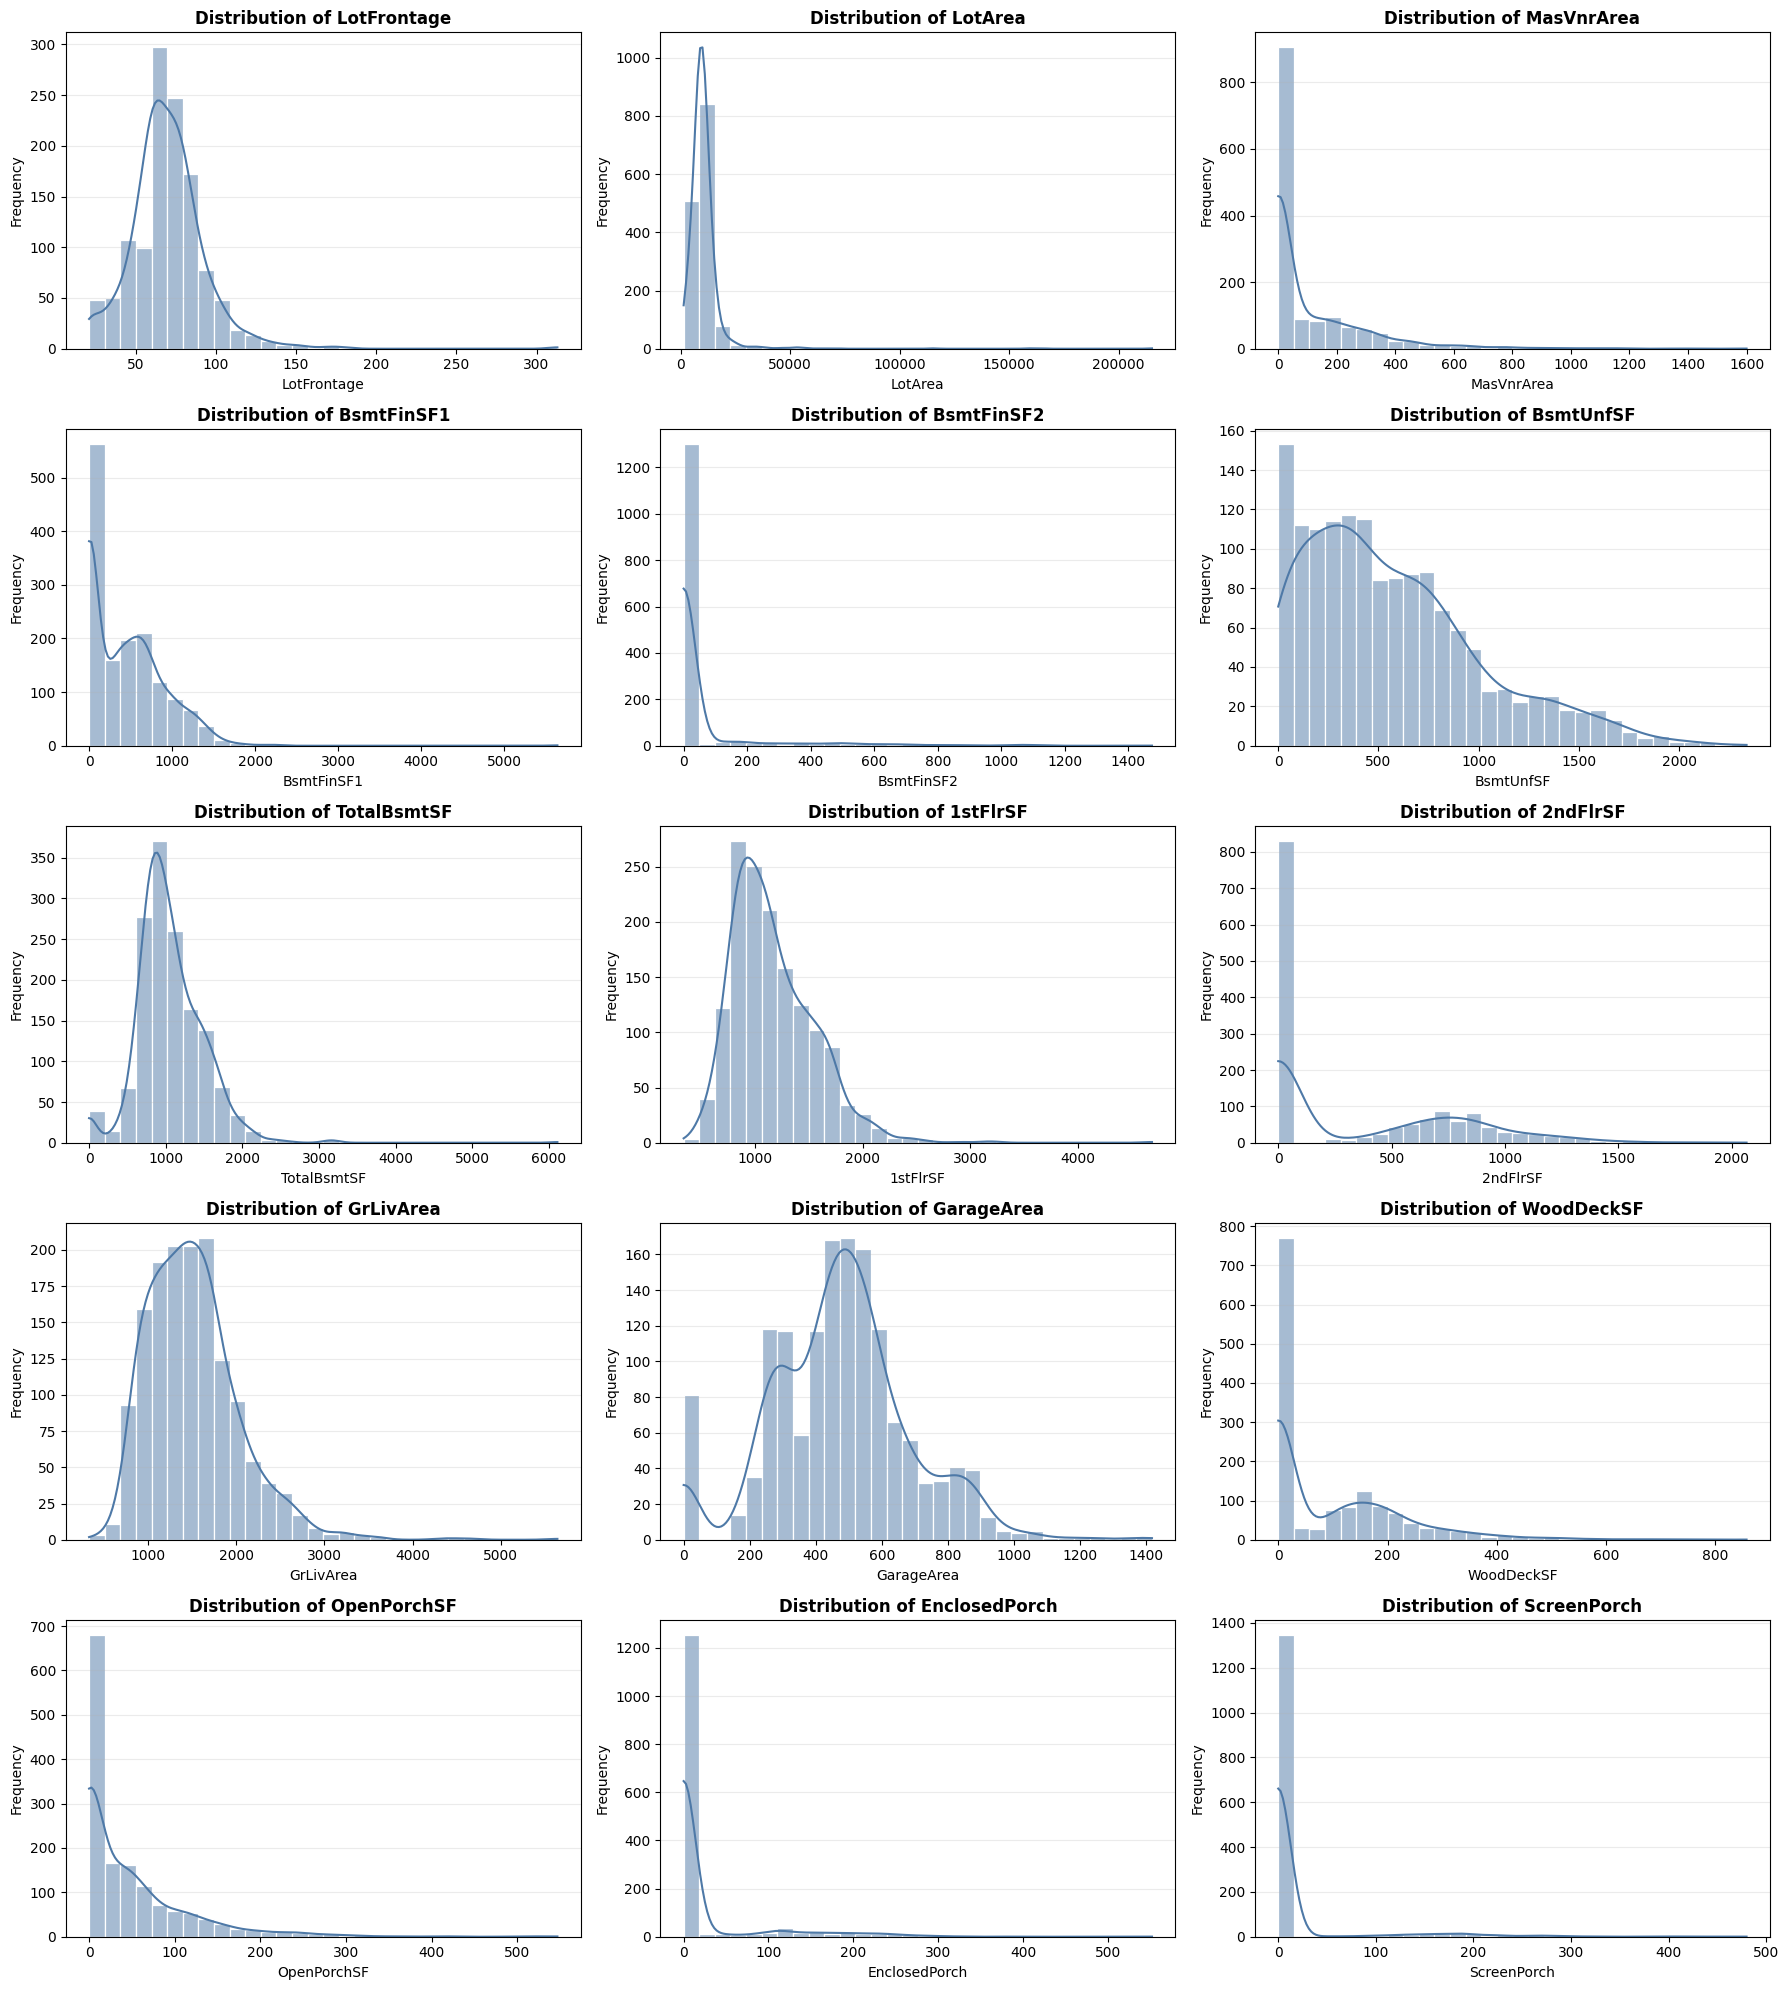

In [52]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(continuous_numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(continuous_numeric_cols):
    sns.histplot(
        data=train_df,
        x=col,
        kde=True,
        bins=30,
        color="#4E79A7",
        edgecolor="white",
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].grid(axis="y", alpha=0.25)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- `LotFrontage`: Moderately right-skewed with some large values; use median imputation for missing values and consider `log1p` or `RobustScaler`.
- `LotArea`: Highly right-skewed with strong extreme values; use `log1p` transformation and consider upper outlier capping.
- `MasVnrArea`: Zero-inflated and right-skewed; fill missing with `0`, create `HasMasVnr`, then apply `log1p`.
- `BsmtFinSF1`: Right-skewed with many zero values; create `HasBsmtFinSF1` and apply `log1p`.
- `BsmtFinSF2`: Mostly zero with few non-zero values; create `HasBsmtFinSF2`, and raw feature can be kept with `log1p` or dropped in a simple baseline.
- `BsmtUnfSF`: Moderately right-skewed but informative; keep the feature and consider `log1p` or scaling.
- `TotalBsmtSF`: Right-skewed with some extreme values; apply `log1p` and check high-value outliers.
- `1stFlrSF`: Right-skewed and likely important; apply `log1p` transformation.
- `2ndFlrSF`: Zero-inflated because many houses have no second floor; create `Has2ndFloor` and apply `log1p`.
- `GrLivArea`: Highly important feature with right skew and outliers; apply `log1p` and inspect extreme large values before capping.
- `GarageArea`: Some zero values and mild right skew; create `HasGarageArea` if needed and apply `log1p`.
- `WoodDeckSF`: Zero-inflated with right skew; create `HasWoodDeck` and apply `log1p`.
- `OpenPorchSF`: Zero-inflated and right-skewed; create `HasOpenPorch` and apply `log1p`.
- `EnclosedPorch`: Mostly zero with few large values; create `HasEnclosedPorch` and apply `log1p` or treat as optional feature.
- `ScreenPorch`: Mostly zero with sparse non-zero values; create `HasScreenPorch` and apply `log1p` or use mainly as binary signal.

### 3.2 Numeric Uniqueness Report

In this section, we will check the uniqueness pattern of auto-detected numeric features.
This helps identify continuous features, repeated count-like features, near-constant features, categorical-like numeric features, and possible ID-like columns.

### Numeric columns select

In [53]:
numeric_cols_38 = auto_numeric_df["column_name"].tolist()

print(f"Total auto-detected numeric columns: {len(numeric_cols_38)}")
numeric_cols_38

Total auto-detected numeric columns: 38


['Id',
 'MSSubClass',
 'LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold',
 'SalePrice']

### Compact uniqueness report function

In [54]:
def create_numeric_uniqueness_report(
    df,
    cols,
    meta_df=None,
    low_cardinality_threshold=30,
    high_cardinality_ratio=0.90,
    near_constant_threshold=0.95
):
    rows = []

    for col in cols:
        s = df[col]
        n_rows = len(s)
        unique_count = s.nunique(dropna=True)
        unique_ratio = unique_count / n_rows

        value_counts = s.value_counts(dropna=False)
        top_value = value_counts.index[0]
        top_count = value_counts.iloc[0]
        top_ratio = top_count / n_rows

        top_3_values = "; ".join([
            f"{idx}: {cnt} ({round(cnt / n_rows * 100, 2)}%)"
            for idx, cnt in value_counts.head(3).items()
        ])

        if unique_count <= low_cardinality_threshold:
            cardinality_level = "low"
        elif unique_ratio >= high_cardinality_ratio:
            cardinality_level = "high"
        else:
            cardinality_level = "medium"

        is_constant = unique_count == 1
        is_near_constant = top_ratio >= near_constant_threshold
        is_categorical_like_numeric = unique_count <= low_cardinality_threshold
        is_id_like_numeric = unique_ratio >= high_cardinality_ratio

        rows.append({
            "column_name": col,
            "pandas_dtype": s.dtype,
            "unique_count": unique_count,
            "unique_ratio": round(unique_ratio, 4),
            "cardinality_level": cardinality_level,
            "top_value": top_value,
            "top_count": top_count,
            "top_ratio": round(top_ratio, 4),
            "is_constant": is_constant,
            "is_near_constant": is_near_constant,
            "is_categorical_like_numeric": is_categorical_like_numeric,
            "is_id_like_numeric": is_id_like_numeric,
            "frequency_rank_top_3": top_3_values
        })

    report_df = pd.DataFrame(rows)

    if meta_df is not None:
        meta_cols = ["column_name", "primary_type", "manual_type"]
        available_meta_cols = [c for c in meta_cols if c in meta_df.columns]

        report_df = report_df.merge(
            meta_df[available_meta_cols],
            on="column_name",
            how="left"
        )

    return report_df

### Create report

In [55]:
numeric_uniqueness_report = create_numeric_uniqueness_report(
    df=train_df,
    cols=numeric_cols_38,
    meta_df=auto_numeric_df
)

numeric_uniqueness_report

,column_name,pandas_dtype,unique_count,unique_ratio,cardinality_level,top_value,top_count,top_ratio,is_constant,is_near_constant,is_categorical_like_numeric,is_id_like_numeric,frequency_rank_top_3,primary_type,manual_type
0,Id,int64,1460,1.0000,high,1460.0,1,0.0007,False,False,False,True,1460: 1 (0.07%); 1: 1 (0.07%); 2: 1 (0.07%),numeric-code,id_like
1,MSSubClass,int64,15,0.0103,low,20.0,536,0.3671,False,False,True,False,20: 536 (36.71%); 60: 299 (20.48%); 50: 144 (9...,ordinal / numeric-category,categorical
2,LotFrontage,float64,110,0.0753,medium,NaN,259,0.1774,False,False,False,False,nan: 259 (17.74%); 60.0: 143 (9.79%); 70.0: 70...,continuous,numeric
3,LotArea,int64,1073,0.7349,medium,7200.0,25,0.0171,False,False,False,False,7200: 25 (1.71%); 9600: 24 (1.64%); 6000: 17 (...,continuous,numeric
4,OverallQual,int64,10,0.0068,low,5.0,397,0.2719,False,False,True,False,5: 397 (27.19%); 6: 374 (25.62%); 7: 319 (21.85%),ordinal / numeric-category,categorical
5,OverallCond,int64,9,0.0062,low,5.0,821,0.5623,False,False,True,False,5: 821 (56.23%); 6: 252 (17.26%); 7: 205 (14.04%),ordinal / numeric-category,categorical
6,YearBuilt,int64,112,0.0767,medium,2006.0,67,0.0459,False,False,False,False,2006: 67 (4.59%); 2005: 64 (4.38%); 2004: 54 (...,year-like,year_like
7,YearRemodAdd,int64,61,0.0418,medium,1950.0,178,0.1219,False,False,False,False,1950: 178 (12.19%); 2006: 97 (6.64%); 2007: 76...,year-like,year_like
8,MasVnrArea,float64,327,0.2240,medium,0.0,861,0.5897,False,False,False,False,0.0: 861 (58.97%); 108.0: 8 (0.55%); nan: 8 (0...,continuous,numeric
9,BsmtFinSF1,int64,637,0.4363,medium,0.0,467,0.3199,False,False,False,False,0: 467 (31.99%); 24: 12 (0.82%); 16: 9 (0.62%),continuous,numeric


### Important flagged features

In [56]:
numeric_uniqueness_report.loc[
    (numeric_uniqueness_report["is_constant"]) |
    (numeric_uniqueness_report["is_near_constant"]) |
    (numeric_uniqueness_report["is_categorical_like_numeric"]) |
    (numeric_uniqueness_report["is_id_like_numeric"])
].sort_values(
    by=["is_id_like_numeric", "is_near_constant", "unique_count"],
    ascending=[False, False, True]
)

,column_name,pandas_dtype,unique_count,unique_ratio,cardinality_level,top_value,top_count,top_ratio,is_constant,is_near_constant,is_categorical_like_numeric,is_id_like_numeric,frequency_rank_top_3,primary_type,manual_type
0,Id,int64,1460,1.0000,high,1460.0,1,0.0007,False,False,False,True,1460: 1 (0.07%); 1: 1 (0.07%); 2: 1 (0.07%),numeric-code,id_like
22,KitchenAbvGr,int64,4,0.0027,low,1.0,1392,0.9534,False,True,True,False,1: 1392 (95.34%); 2: 65 (4.45%); 3: 2 (0.14%),count,numeric
33,PoolArea,int64,8,0.0055,low,0.0,1453,0.9952,False,True,True,False,0: 1453 (99.52%); 512: 1 (0.07%); 648: 1 (0.07%),count,numeric
31,3SsnPorch,int64,20,0.0137,low,0.0,1436,0.9836,False,True,True,False,0: 1436 (98.36%); 168: 3 (0.21%); 180: 2 (0.14%),count,numeric
34,MiscVal,int64,21,0.0144,low,0.0,1408,0.9644,False,True,True,False,0: 1408 (96.44%); 400: 11 (0.75%); 500: 8 (0.55%),count,numeric
15,LowQualFinSF,int64,24,0.0164,low,0.0,1434,0.9822,False,True,True,False,0: 1434 (98.22%); 80: 3 (0.21%); 360: 2 (0.14%),count,numeric
18,BsmtHalfBath,int64,3,0.0021,low,0.0,1378,0.9438,False,False,True,False,0: 1378 (94.38%); 1: 80 (5.48%); 2: 2 (0.14%),count,numeric
20,HalfBath,int64,3,0.0021,low,0.0,913,0.6253,False,False,True,False,0: 913 (62.53%); 1: 535 (36.64%); 2: 12 (0.82%),count,numeric
17,BsmtFullBath,int64,4,0.0027,low,0.0,856,0.5863,False,False,True,False,0: 856 (58.63%); 1: 588 (40.27%); 2: 15 (1.03%),count,numeric
19,FullBath,int64,4,0.0027,low,2.0,768,0.5260,False,False,True,False,2: 768 (52.6%); 1: 650 (44.52%); 3: 33 (2.26%),count,numeric


### Summary count

In [57]:
numeric_uniqueness_summary = pd.DataFrame({
    "metric": [
        "constant_features",
        "near_constant_features",
        "categorical_like_numeric_features",
        "id_like_numeric_features",
        "low_cardinality_features",
        "medium_cardinality_features",
        "high_cardinality_features"
    ],
    "count": [
        numeric_uniqueness_report["is_constant"].sum(),
        numeric_uniqueness_report["is_near_constant"].sum(),
        numeric_uniqueness_report["is_categorical_like_numeric"].sum(),
        numeric_uniqueness_report["is_id_like_numeric"].sum(),
        (numeric_uniqueness_report["cardinality_level"] == "low").sum(),
        (numeric_uniqueness_report["cardinality_level"] == "medium").sum(),
        (numeric_uniqueness_report["cardinality_level"] == "high").sum()
    ]
})

numeric_uniqueness_summary

,metric,count
0,constant_features,0
1,near_constant_features,5
2,categorical_like_numeric_features,18
3,id_like_numeric_features,1
4,low_cardinality_features,18
5,medium_cardinality_features,19
6,high_cardinality_features,1


### Top repeated value structure

In [58]:
numeric_uniqueness_report[
    [
        "column_name",
        "unique_count",
        "unique_ratio",
        "top_value",
        "top_count",
        "top_ratio",
        "frequency_rank_top_3",
        "primary_type",
        "manual_type"
    ]
].sort_values("top_ratio", ascending=False)

,column_name,unique_count,unique_ratio,top_value,top_count,top_ratio,frequency_rank_top_3,primary_type,manual_type
33,PoolArea,8,0.0055,0.0,1453,0.9952,0: 1453 (99.52%); 512: 1 (0.07%); 648: 1 (0.07%),count,numeric
31,3SsnPorch,20,0.0137,0.0,1436,0.9836,0: 1436 (98.36%); 168: 3 (0.21%); 180: 2 (0.14%),count,numeric
15,LowQualFinSF,24,0.0164,0.0,1434,0.9822,0: 1434 (98.22%); 80: 3 (0.21%); 360: 2 (0.14%),count,numeric
34,MiscVal,21,0.0144,0.0,1408,0.9644,0: 1408 (96.44%); 400: 11 (0.75%); 500: 8 (0.55%),count,numeric
22,KitchenAbvGr,4,0.0027,1.0,1392,0.9534,1: 1392 (95.34%); 2: 65 (4.45%); 3: 2 (0.14%),count,numeric
18,BsmtHalfBath,3,0.0021,0.0,1378,0.9438,0: 1378 (94.38%); 1: 80 (5.48%); 2: 2 (0.14%),count,numeric
32,ScreenPorch,76,0.0521,0.0,1344,0.9205,0: 1344 (92.05%); 192: 6 (0.41%); 120: 5 (0.34%),continuous,numeric
10,BsmtFinSF2,144,0.0986,0.0,1293,0.8856,0: 1293 (88.56%); 180: 5 (0.34%); 374: 3 (0.21%),continuous,numeric
30,EnclosedPorch,120,0.0822,0.0,1252,0.8575,0: 1252 (85.75%); 112: 15 (1.03%); 96: 6 (0.41%),continuous,numeric
20,HalfBath,3,0.0021,0.0,913,0.6253,0: 913 (62.53%); 1: 535 (36.64%); 2: 12 (0.82%),count,numeric


### Unique Percentage Horizontal Bar Chart

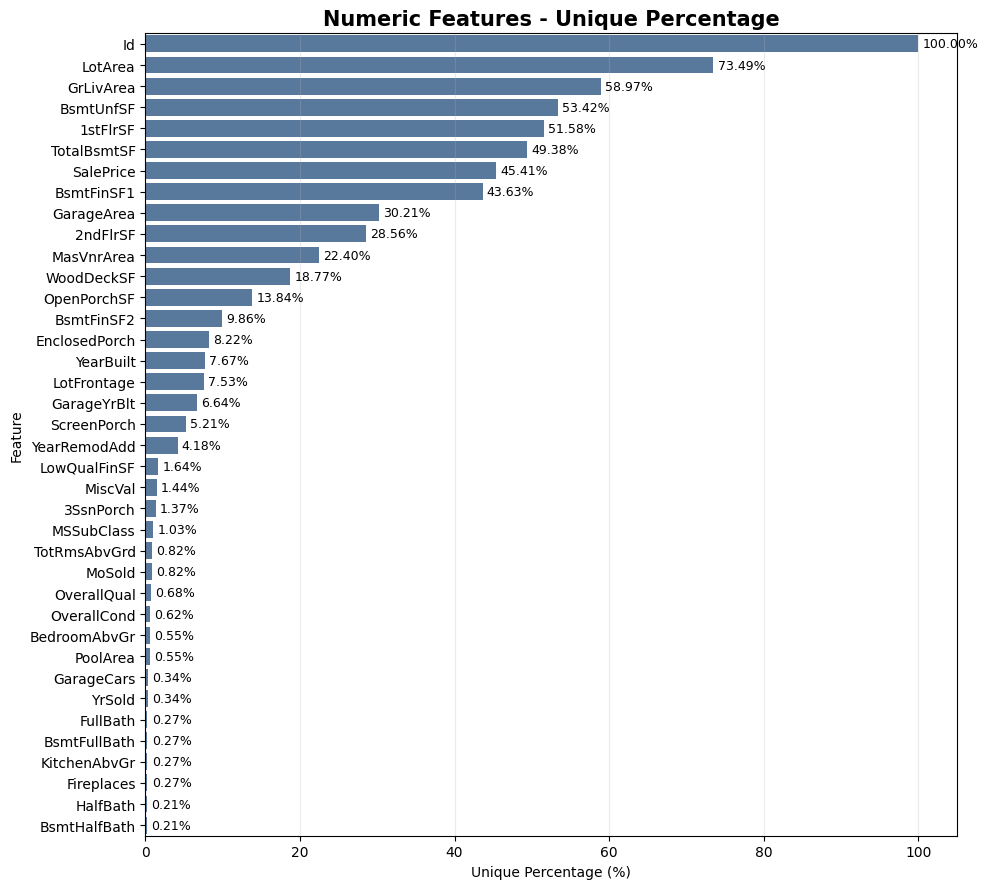

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = numeric_uniqueness_report.copy()
plot_df["unique_percentage"] = (plot_df["unique_ratio"] * 100).round(2)

plot_df = plot_df.sort_values("unique_percentage", ascending=False)

plt.figure(figsize=(10, 9))

ax = sns.barplot(
    data=plot_df,
    x="unique_percentage",
    y="column_name",
    color="#4E79A7"
)

plt.title("Numeric Features - Unique Percentage", fontsize=15, fontweight="bold")
plt.xlabel("Unique Percentage (%)")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=9)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Cardinality Level Count Chart

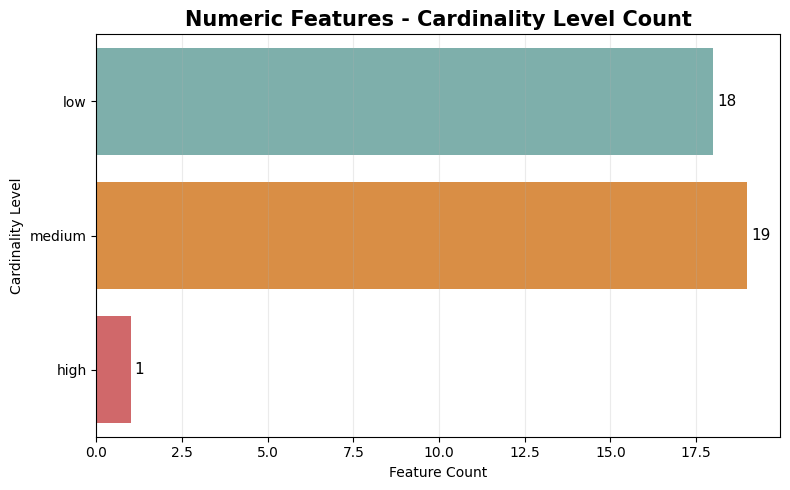

In [60]:
cardinality_plot_df = (
    numeric_uniqueness_report["cardinality_level"]
    .value_counts()
    .reset_index()
)

cardinality_plot_df.columns = ["cardinality_level", "count"]

order = ["low", "medium", "high"]
cardinality_plot_df["cardinality_level"] = pd.Categorical(
    cardinality_plot_df["cardinality_level"],
    categories=order,
    ordered=True
)

cardinality_plot_df = cardinality_plot_df.sort_values("cardinality_level")

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=cardinality_plot_df,
    x="count",
    y="cardinality_level",
    palette=["#76B7B2", "#F28E2C", "#E15759"]
)

plt.title("Numeric Features - Cardinality Level Count", fontsize=15, fontweight="bold")
plt.xlabel("Feature Count")
plt.ylabel("Cardinality Level")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=11)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

# cardinality level with feture

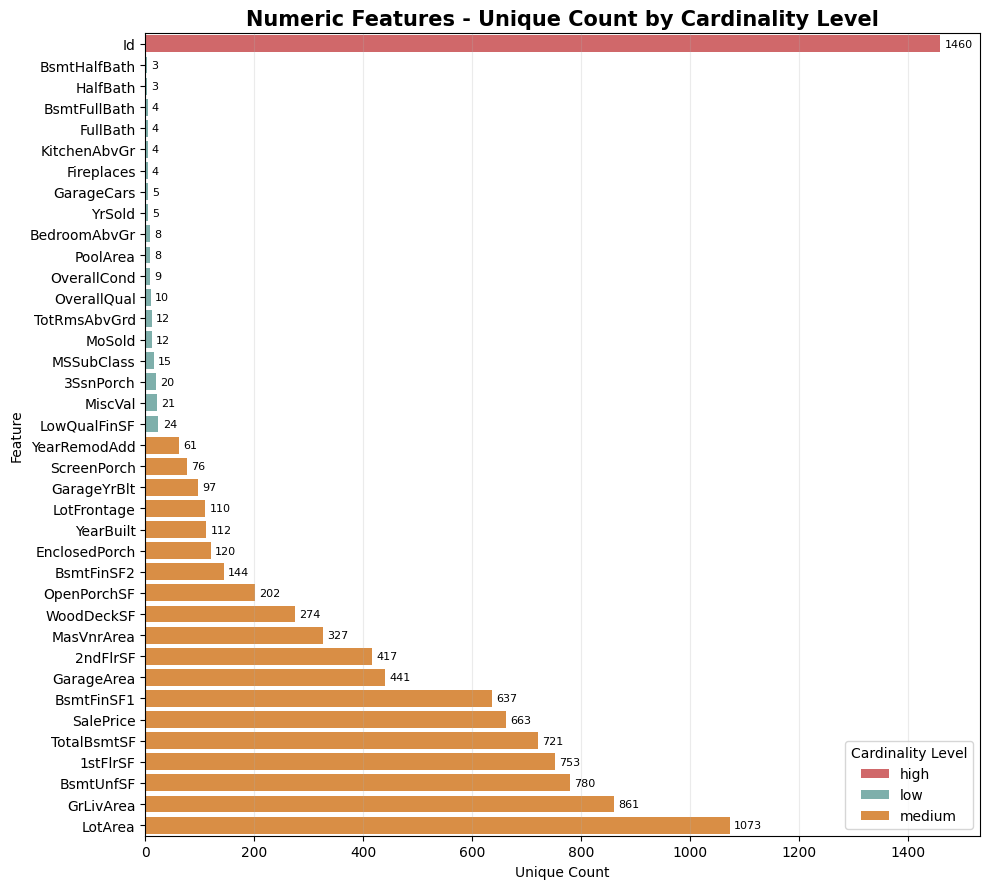

In [61]:
plot_df = numeric_uniqueness_report.sort_values(
    ["cardinality_level", "unique_count"],
    ascending=[True, True]
)

plt.figure(figsize=(10, 9))

ax = sns.barplot(
    data=plot_df,
    x="unique_count",
    y="column_name",
    hue="cardinality_level",
    palette={
        "low": "#76B7B2",
        "medium": "#F28E2C",
        "high": "#E15759"
    }
)

plt.title("Numeric Features - Unique Count by Cardinality Level", fontsize=15, fontweight="bold")
plt.xlabel("Unique Count")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=8)

plt.grid(axis="x", alpha=0.25)
plt.legend(title="Cardinality Level")
plt.tight_layout()
plt.show()

The uniqueness report shows that `Id` has fully unique values, so it behaves like an ID-like feature and should not be used as a predictive numerical feature.
Most count-based features such as `BsmtHalfBath`, `HalfBath`, `FullBath`, `KitchenAbvGr`, `Fireplaces`, and `GarageCars` have low cardinality, so they should be analyzed as discrete/count features.
Features like `LotArea`, `GrLivArea`, `BsmtUnfSF`, `1stFlrSF`, and `TotalBsmtSF` have medium-to-high uniqueness, so they behave more like continuous numerical features.
Overall, this report confirms that auto-detected numeric columns contain mixed behavior: ID-like, discrete/count, ordinal/category-like, year-like, and true continuous features.

### 3.3 Numeric Missing Value Report

In this section, we will check missing values in auto-detected numeric features and generate logical imputation hints.
This report will help us decide whether to use median, mode, zero, indicator flags, or manual review before modeling.

In [76]:
pure_numeric_cols = house_column_summary.loc[
    house_column_summary["final_corrected_type"].astype(str).str.lower() == "numeric",
    "column"
].tolist()

print(f"Total main numerical features: {len(pure_numeric_cols)}")
pure_numeric_cols

Total main numerical features: 28


['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal']

In [77]:
import numpy as np
import pandas as pd

def create_pure_numeric_missing_report(df, numeric_cols, target_col="SalePrice"):
    rows = []

    for col in numeric_cols:
        s = df[col]
        missing_count = s.isnull().sum()
        missing_percentage = round(s.isnull().mean() * 100, 2)
        zero_percentage = round((s.fillna(0) == 0).mean() * 100, 2)
        skewness = round(s.skew(), 3)

        if missing_percentage == 0:
            missing_status = "no missing"
        elif missing_percentage < 5:
            missing_status = "low"
        elif missing_percentage < 20:
            missing_status = "moderate"
        else:
            missing_status = "high"

        if missing_count > 0:
            target_missing_median = df.loc[s.isnull(), target_col].median()
            target_not_missing_median = df.loc[s.notnull(), target_col].median()
            target_gap_pct = round(
                ((target_missing_median - target_not_missing_median) / target_not_missing_median) * 100,
                2
            )
        else:
            target_missing_median = np.nan
            target_not_missing_median = np.nan
            target_gap_pct = np.nan

        if missing_percentage == 0:
            imputation_hint = "No imputation needed"
        elif col == "MasVnrArea":
            imputation_hint = "Fill 0 + create HasMasVnr indicator"
        elif missing_percentage >= 5:
            imputation_hint = "Median imputation + missing indicator"
        else:
            imputation_hint = "Median imputation"

        rows.append({
            "column_name": col,
            "dtype": s.dtype,
            "missing_count": missing_count,
            "missing_percentage": missing_percentage,
            "missing_status": missing_status,
            "zero_percentage": zero_percentage,
            "skewness": skewness,
            "target_median_when_missing": target_missing_median,
            "target_median_when_not_missing": target_not_missing_median,
            "target_gap_percentage": target_gap_pct,
            "imputation_hint": imputation_hint
        })

    return pd.DataFrame(rows)

In [78]:
pure_numeric_missing_report = create_pure_numeric_missing_report(
    df=train_df,
    numeric_cols=pure_numeric_cols,
    target_col="SalePrice"
)

pure_numeric_missing_report.sort_values("missing_percentage", ascending=False)

,column_name,dtype,missing_count,missing_percentage,missing_status,zero_percentage,skewness,target_median_when_missing,target_median_when_not_missing,target_gap_percentage,imputation_hint
0,LotFrontage,float64,259,17.74,moderate,17.74,2.164,172400.0,159500.0,8.09,Median imputation + missing indicator
2,MasVnrArea,float64,8,0.55,low,59.52,2.669,203287.0,162700.0,24.95,Fill 0 + create HasMasVnr indicator
1,LotArea,int64,0,0.00,no missing,0.00,12.208,NaN,NaN,NaN,No imputation needed
3,BsmtFinSF1,int64,0,0.00,no missing,31.99,1.686,NaN,NaN,NaN,No imputation needed
4,BsmtFinSF2,int64,0,0.00,no missing,88.56,4.255,NaN,NaN,NaN,No imputation needed
5,BsmtUnfSF,int64,0,0.00,no missing,8.08,0.920,NaN,NaN,NaN,No imputation needed
6,TotalBsmtSF,int64,0,0.00,no missing,2.53,1.524,NaN,NaN,NaN,No imputation needed
7,1stFlrSF,int64,0,0.00,no missing,0.00,1.377,NaN,NaN,NaN,No imputation needed
8,2ndFlrSF,int64,0,0.00,no missing,56.78,0.813,NaN,NaN,NaN,No imputation needed
9,LowQualFinSF,int64,0,0.00,no missing,98.22,9.011,NaN,NaN,NaN,No imputation needed


In [79]:
pure_numeric_missing_features = (
    pure_numeric_missing_report
    .loc[pure_numeric_missing_report["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
    .reset_index(drop=True)
)

pure_numeric_missing_features

,column_name,dtype,missing_count,missing_percentage,missing_status,zero_percentage,skewness,target_median_when_missing,target_median_when_not_missing,target_gap_percentage,imputation_hint
0,LotFrontage,float64,259,17.74,moderate,17.74,2.164,172400.0,159500.0,8.09,Median imputation + missing indicator
1,MasVnrArea,float64,8,0.55,low,59.52,2.669,203287.0,162700.0,24.95,Fill 0 + create HasMasVnr indicator


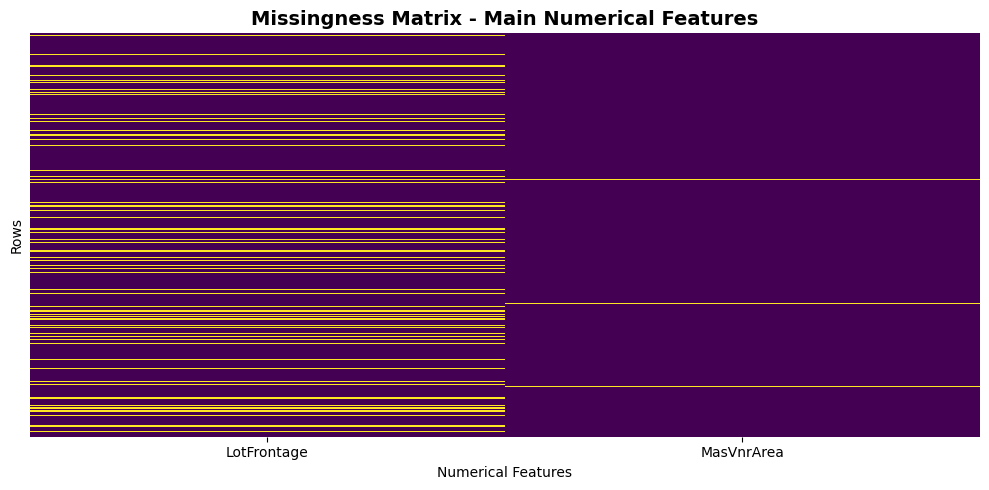

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_missing_cols = pure_numeric_missing_features["column_name"].tolist()

if len(numeric_missing_cols) > 0:
    plt.figure(figsize=(10, 5))

    sns.heatmap(
        train_df[numeric_missing_cols].isnull(),
        cbar=False,
        yticklabels=False,
        cmap="viridis"
    )

    plt.title("Missingness Matrix - Main Numerical Features", fontsize=14, fontweight="bold")
    plt.xlabel("Numerical Features")
    plt.ylabel("Rows")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in main numerical features.")

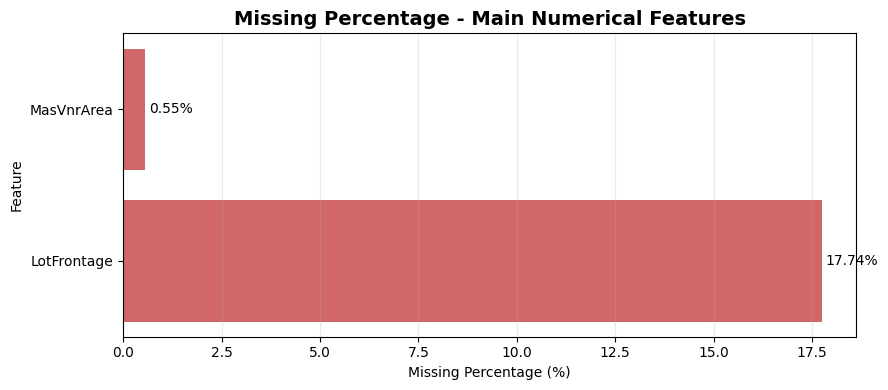

In [81]:
if len(pure_numeric_missing_features) > 0:
    plot_df = pure_numeric_missing_features.sort_values("missing_percentage", ascending=True)

    plt.figure(figsize=(9, 4))

    ax = sns.barplot(
        data=plot_df,
        x="missing_percentage",
        y="column_name",
        color="#E15759"
    )

    plt.title("Missing Percentage - Main Numerical Features", fontsize=14, fontweight="bold")
    plt.xlabel("Missing Percentage (%)")
    plt.ylabel("Feature")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f%%", padding=3, fontsize=10)

    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found in main numerical features.")

In [82]:
pure_numeric_imputation_plan = pure_numeric_missing_features[
    [
        "column_name",
        "missing_count",
        "missing_percentage",
        "missing_status",
        "zero_percentage",
        "target_gap_percentage",
        "imputation_hint"
    ]
]

pure_numeric_imputation_plan

,column_name,missing_count,missing_percentage,missing_status,zero_percentage,target_gap_percentage,imputation_hint
0,LotFrontage,259,17.74,moderate,17.74,8.09,Median imputation + missing indicator
1,MasVnrArea,8,0.55,low,59.52,24.95,Fill 0 + create HasMasVnr indicator


Only **2 main numerical features** have missing values: `LotFrontage` and `MasVnrArea`; no pure numerical feature needs to be dropped because of missingness.
`LotFrontage` has **17.74%** missing values, so we will use **median imputation + missing indicator** to preserve possible missingness signal.
`MasVnrArea` has only **0.55%** missing values but many zero values, so we will fill missing values with **0** and create a `HasMasVnr` indicator.

### 3.4 Numeric Central Tendency Report

In this section, we will analyze the central tendency of the 28 main numerical features using mean, median, mode, and mode dominance.
This helps us understand whether a feature is stable, shifted/skewed, or dominated by a repeated value, and gives an initial imputation direction.

In [93]:
pure_numeric_cols = house_column_summary.loc[
    house_column_summary["final_corrected_type"].astype(str).str.lower() == "numeric",
    "column"
].tolist()

print(f"Total main numerical features: {len(pure_numeric_cols)}")
pure_numeric_cols

Total main numerical features: 28


['LotFrontage',
 'LotArea',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal']

In [94]:
import numpy as np
import pandas as pd

def create_numeric_central_tendency_report(df, numeric_cols):
    rows = []

    for col in numeric_cols:
        s = df[col].dropna()

        mean_value = s.mean()
        median_value = s.median()
        mode_value = s.mode().iloc[0] if not s.mode().empty else np.nan

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        mode_count = (s == mode_value).sum()
        mode_percentage = (mode_count / len(s)) * 100

        zero_count = (s == 0).sum()
        zero_percentage = (zero_count / len(s)) * 100

        mean_median_gap = mean_value - median_value

        # Safe percentage gap
        if median_value != 0:
            mean_median_gap_percentage = (mean_median_gap / median_value) * 100
        else:
            mean_median_gap_percentage = np.nan

        # Better backup when median is 0
        if iqr != 0:
            gap_to_iqr_percentage = (abs(mean_median_gap) / iqr) * 100
        else:
            gap_to_iqr_percentage = np.nan

        # Center stability decision
        if zero_percentage >= 80:
            center_stability = "zero-dominated"
        elif mode_percentage >= 80:
            center_stability = "mode-dominated"
        elif pd.notna(mean_median_gap_percentage) and abs(mean_median_gap_percentage) <= 5:
            center_stability = "stable"
        elif pd.notna(mean_median_gap_percentage) and abs(mean_median_gap_percentage) <= 20:
            center_stability = "slightly shifted"
        elif pd.notna(gap_to_iqr_percentage) and gap_to_iqr_percentage <= 25:
            center_stability = "slightly shifted"
        else:
            center_stability = "shifted"

        # Imputation hint
        if zero_percentage >= 80:
            imputation_candidate = "zero/indicator check"
        elif center_stability == "stable":
            imputation_candidate = "mean or median"
        elif center_stability == "slightly shifted":
            imputation_candidate = "median preferred"
        else:
            imputation_candidate = "median / transformation check"

        rows.append({
            "column_name": col,
            "mean": round(mean_value, 2),
            "median": round(median_value, 2),
            "mode": mode_value,
            "mode_percentage": round(mode_percentage, 2),
            "zero_percentage": round(zero_percentage, 2),
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "mean_median_gap": round(mean_median_gap, 2),
            "mean_median_gap_percentage": round(mean_median_gap_percentage, 2) if pd.notna(mean_median_gap_percentage) else np.nan,
            "gap_to_iqr_percentage": round(gap_to_iqr_percentage, 2) if pd.notna(gap_to_iqr_percentage) else np.nan,
            "center_stability": center_stability,
            "imputation_candidate": imputation_candidate
        })

    return pd.DataFrame(rows)

In [95]:
numeric_central_tendency_report = create_numeric_central_tendency_report(
    df=train_df,
    numeric_cols=pure_numeric_cols
)

numeric_central_tendency_report

,column_name,mean,median,mode,mode_percentage,zero_percentage,q1,q3,iqr,mean_median_gap,mean_median_gap_percentage,gap_to_iqr_percentage,center_stability,imputation_candidate
0,LotFrontage,70.05,69.0,60.0,11.91,0.00,59.00,80.00,21.00,1.05,1.52,5.00,stable,mean or median
1,LotArea,10516.83,9478.5,7200.0,1.71,0.00,7553.50,11601.50,4048.00,1038.33,10.95,25.65,slightly shifted,median preferred
2,MasVnrArea,103.69,0.0,0.0,59.30,59.30,0.00,166.00,166.00,103.69,NaN,62.46,shifted,median / transformation check
3,BsmtFinSF1,443.64,383.5,0.0,31.99,31.99,0.00,712.25,712.25,60.14,15.68,8.44,slightly shifted,median preferred
4,BsmtFinSF2,46.55,0.0,0.0,88.56,88.56,0.00,0.00,0.00,46.55,NaN,NaN,zero-dominated,zero/indicator check
5,BsmtUnfSF,567.24,477.5,0.0,8.08,8.08,223.00,808.00,585.00,89.74,18.79,15.34,slightly shifted,median preferred
6,TotalBsmtSF,1057.43,991.5,0.0,2.53,2.53,795.75,1298.25,502.50,65.93,6.65,13.12,slightly shifted,median preferred
7,1stFlrSF,1162.63,1087.0,864.0,1.71,0.00,882.00,1391.25,509.25,75.63,6.96,14.85,slightly shifted,median preferred
8,2ndFlrSF,346.99,0.0,0.0,56.78,56.78,0.00,728.00,728.00,346.99,NaN,47.66,shifted,median / transformation check
9,LowQualFinSF,5.84,0.0,0.0,98.22,98.22,0.00,0.00,0.00,5.84,NaN,NaN,zero-dominated,zero/indicator check


In [96]:
numeric_center_summary = (
    numeric_central_tendency_report["center_stability"]
    .value_counts()
    .reset_index()
)

numeric_center_summary.columns = ["center_stability", "feature_count"]

numeric_center_summary

,center_stability,feature_count
0,shifted,8
1,zero-dominated,8
2,slightly shifted,7
3,stable,4
4,mode-dominated,1


In [97]:
numeric_center_review_features = (
    numeric_central_tendency_report
    .loc[
        numeric_central_tendency_report["center_stability"].isin(
            ["zero-dominated", "mode-dominated", "shifted"]
        )
    ]
    .sort_values(
        by=["zero_percentage", "mode_percentage", "gap_to_iqr_percentage"],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

numeric_center_review_features

,column_name,mean,median,mode,mode_percentage,zero_percentage,q1,q3,iqr,mean_median_gap,mean_median_gap_percentage,gap_to_iqr_percentage,center_stability,imputation_candidate
0,PoolArea,2.76,0.0,0.0,99.52,99.52,0.0,0.0,0.0,2.76,NaN,NaN,zero-dominated,zero/indicator check
1,3SsnPorch,3.41,0.0,0.0,98.36,98.36,0.0,0.0,0.0,3.41,NaN,NaN,zero-dominated,zero/indicator check
2,LowQualFinSF,5.84,0.0,0.0,98.22,98.22,0.0,0.0,0.0,5.84,NaN,NaN,zero-dominated,zero/indicator check
3,MiscVal,43.49,0.0,0.0,96.44,96.44,0.0,0.0,0.0,43.49,NaN,NaN,zero-dominated,zero/indicator check
4,BsmtHalfBath,0.06,0.0,0.0,94.38,94.38,0.0,0.0,0.0,0.06,NaN,NaN,zero-dominated,zero/indicator check
5,ScreenPorch,15.06,0.0,0.0,92.05,92.05,0.0,0.0,0.0,15.06,NaN,NaN,zero-dominated,zero/indicator check
6,BsmtFinSF2,46.55,0.0,0.0,88.56,88.56,0.0,0.0,0.0,46.55,NaN,NaN,zero-dominated,zero/indicator check
7,EnclosedPorch,21.95,0.0,0.0,85.75,85.75,0.0,0.0,0.0,21.95,NaN,NaN,zero-dominated,zero/indicator check
8,HalfBath,0.38,0.0,0.0,62.53,62.53,0.0,1.0,1.0,0.38,NaN,38.29,shifted,median / transformation check
9,MasVnrArea,103.69,0.0,0.0,59.30,59.30,0.0,166.0,166.0,103.69,NaN,62.46,shifted,median / transformation check


In [98]:
numeric_central_tendency_report[
    [
        "column_name",
        "mean",
        "median",
        "mode",
        "mode_percentage",
        "zero_percentage",
        "mean_median_gap",
        "mean_median_gap_percentage",
        "gap_to_iqr_percentage",
        "center_stability",
        "imputation_candidate"
    ]
].sort_values(
    by=["center_stability", "zero_percentage"],
    ascending=[True, False]
)

,column_name,mean,median,mode,mode_percentage,zero_percentage,mean_median_gap,mean_median_gap_percentage,gap_to_iqr_percentage,center_stability,imputation_candidate
16,KitchenAbvGr,1.05,1.0,1.0,95.34,0.07,0.05,4.66,NaN,mode-dominated,median / transformation check
14,HalfBath,0.38,0.0,0.0,62.53,62.53,0.38,NaN,38.29,shifted,median / transformation check
2,MasVnrArea,103.69,0.0,0.0,59.30,59.30,103.69,NaN,62.46,shifted,median / transformation check
11,BsmtFullBath,0.43,0.0,0.0,58.63,58.63,0.43,NaN,42.53,shifted,median / transformation check
8,2ndFlrSF,346.99,0.0,0.0,56.78,56.78,346.99,NaN,47.66,shifted,median / transformation check
21,WoodDeckSF,94.24,0.0,0.0,52.12,52.12,94.24,NaN,56.10,shifted,median / transformation check
18,Fireplaces,0.61,1.0,0.0,47.26,47.26,-0.39,-38.70,38.70,shifted,median / transformation check
22,OpenPorchSF,46.66,25.0,0.0,44.93,44.93,21.66,86.64,31.85,shifted,median / transformation check
13,FullBath,1.57,2.0,2.0,52.60,0.62,-0.43,-21.75,43.49,shifted,median / transformation check
3,BsmtFinSF1,443.64,383.5,0.0,31.99,31.99,60.14,15.68,8.44,slightly shifted,median preferred


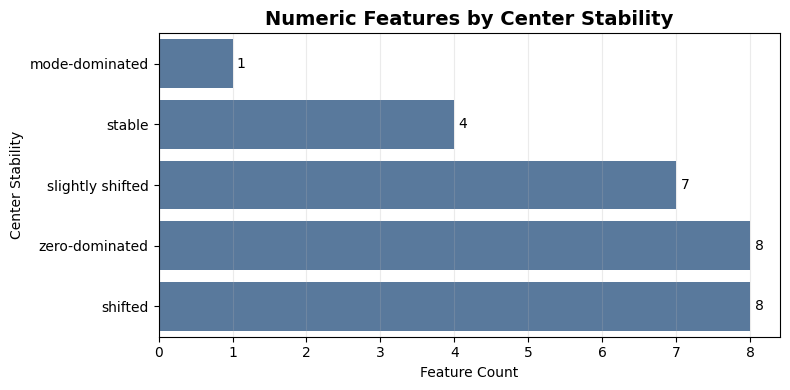

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = numeric_center_summary.sort_values("feature_count", ascending=True)

plt.figure(figsize=(8, 4))

ax = sns.barplot(
    data=plot_df,
    x="feature_count",
    y="center_stability",
    color="#4E79A7"
)

plt.title("Numeric Features by Center Stability", fontsize=14, fontweight="bold")
plt.xlabel("Feature Count")
plt.ylabel("Center Stability")

for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=10)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

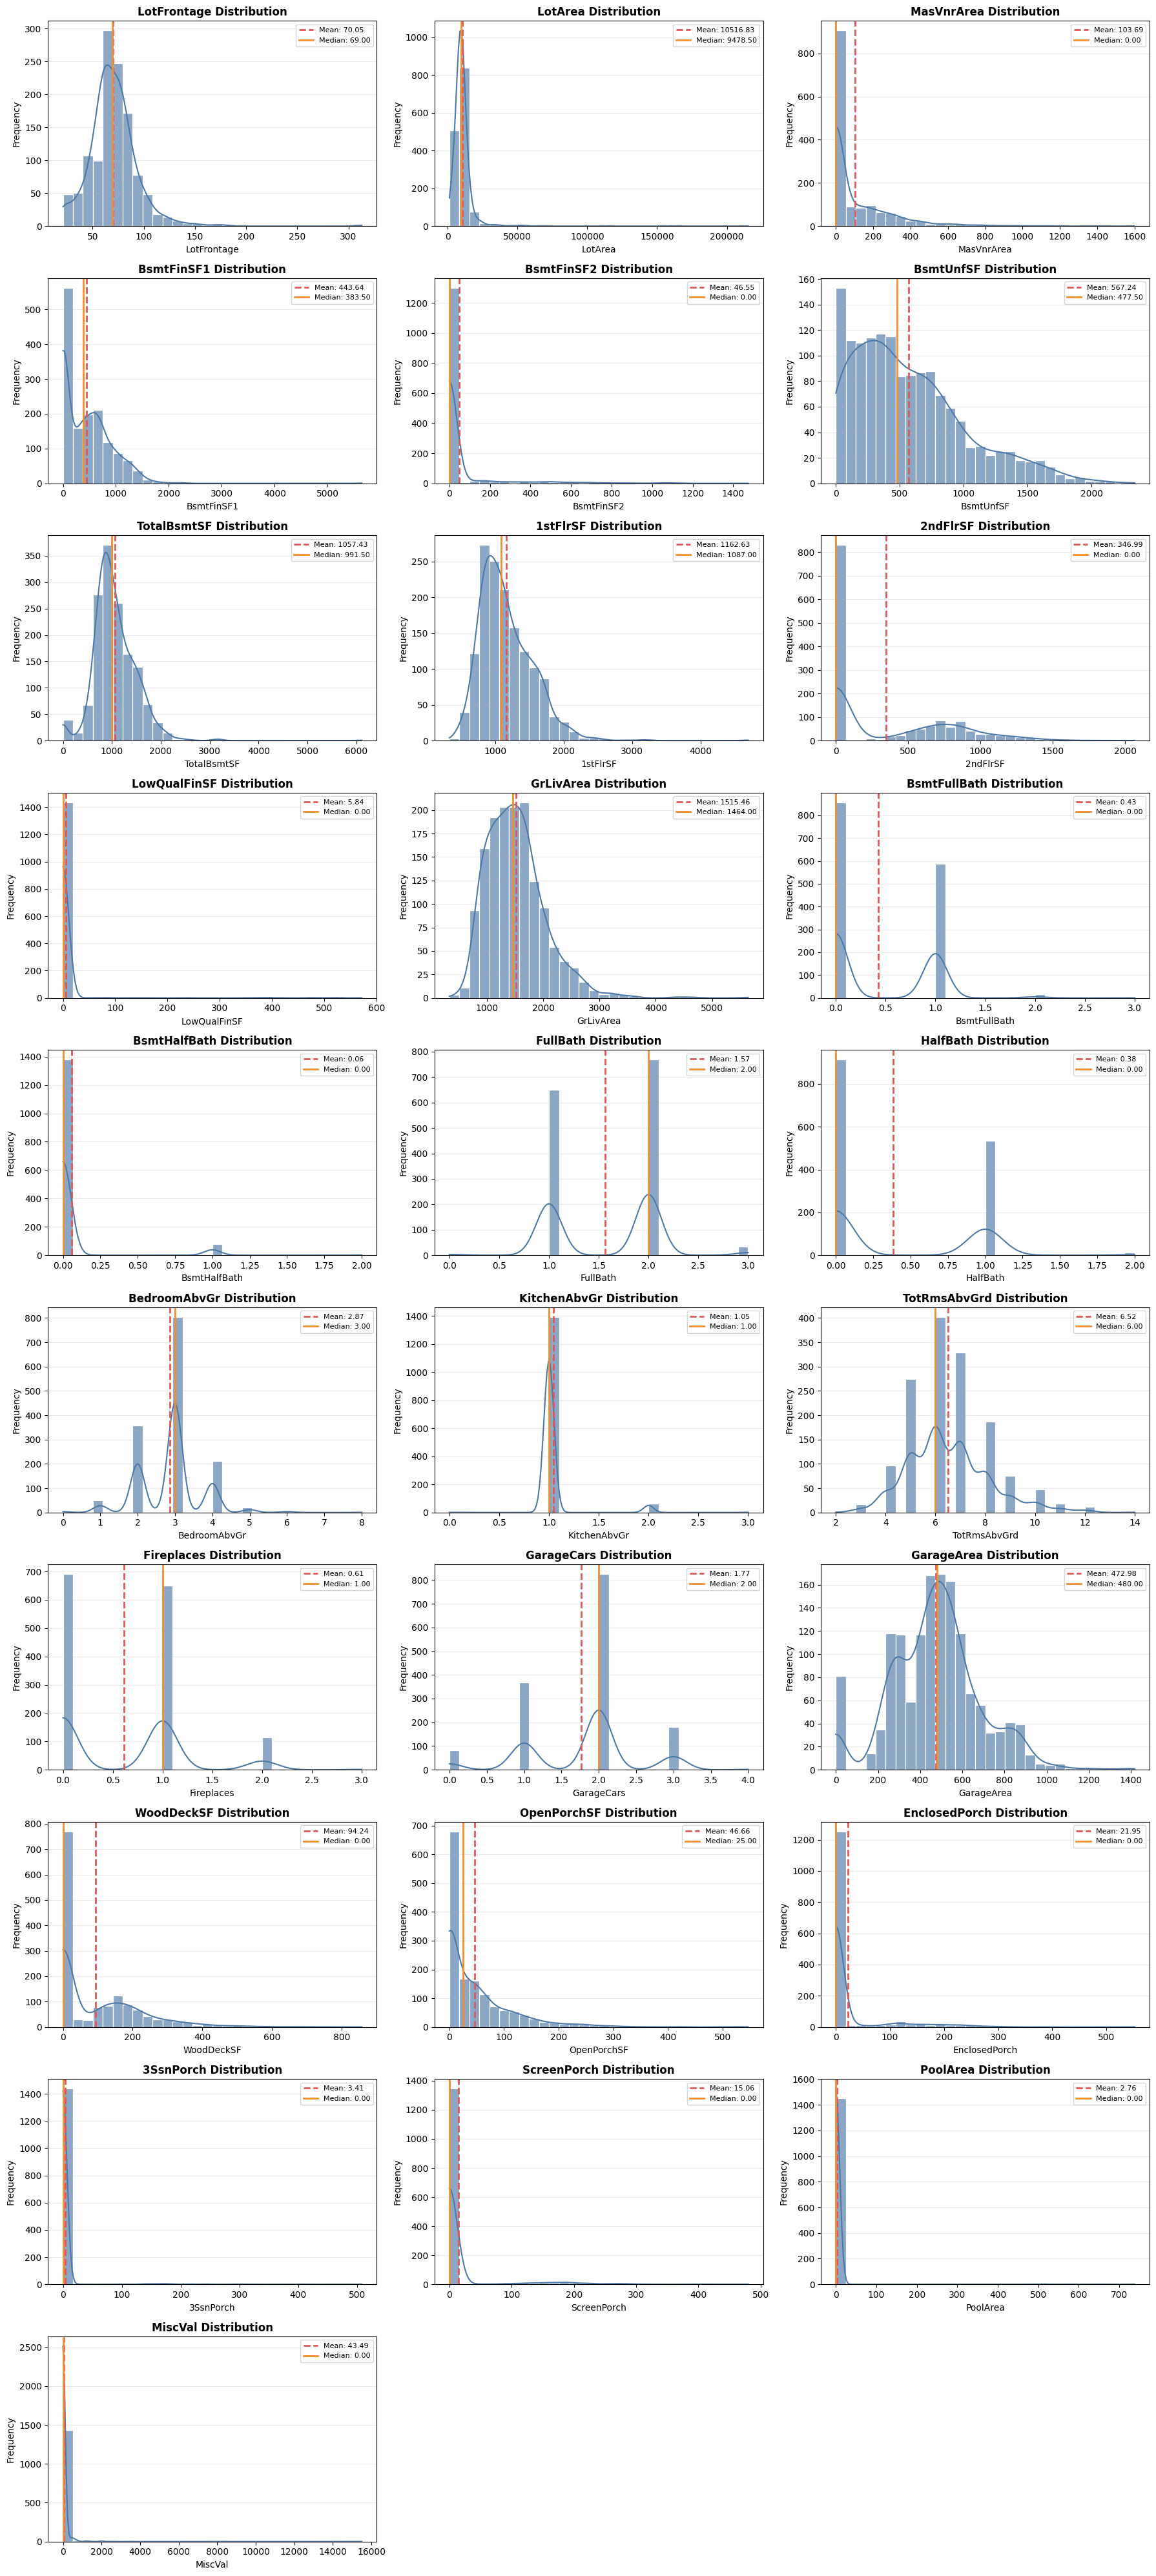

In [100]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram with mean and median lines for all pure numeric features
n_cols = 3
n_rows = math.ceil(len(pure_numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(pure_numeric_cols):
    s = train_df[col].dropna()

    mean_value = s.mean()
    median_value = s.median()

    sns.histplot(
        s,
        bins=30,
        kde=True,
        color="#4E79A7",
        edgecolor="white",
        alpha=0.65,
        ax=axes[i]
    )

    axes[i].axvline(
        mean_value,
        color="#E15759",
        linestyle="--",
        linewidth=2,
        label=f"Mean: {mean_value:.2f}"
    )

    axes[i].axvline(
        median_value,
        color="#F28E2C",
        linestyle="-",
        linewidth=2,
        label=f"Median: {median_value:.2f}"
    )

    axes[i].set_title(f"{col} Distribution", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")
    axes[i].legend(fontsize=8)
    axes[i].grid(axis="y", alpha=0.25)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [101]:
numeric_central_tendency_report.to_csv("3.central_tendancy.csv")

### Manual Decision from Numeric Central Tendency

The numerical features show mixed behavior: some have stable centers, some are right-skewed, and many are zero-dominated.  
For stable features, mean/median is reliable; for skewed features, median/log transformation is better; for zero-heavy features, binary indicator features should be considered.

| Feature | Manual Decision |
|---|---|
| `LotFrontage` | Stable center; use median imputation if missing, no strong transformation needed. |
| `LotArea` | Right-skewed; apply `log1p` and check high outliers. |
| `MasVnrArea` | Zero-heavy and shifted; fill missing with `0`, create `HasMasVnr`, then use `log1p`. |
| `BsmtFinSF1` | Slightly shifted with many zeros; keep, use `log1p`, optionally create `HasBsmtFinSF1`. |
| `BsmtFinSF2` | Strongly zero-dominated; create `HasBsmtFinSF2`, raw feature may be less important. |
| `BsmtUnfSF` | Slightly shifted but useful; keep and use median/scaling if needed. |
| `TotalBsmtSF` | Slightly right-skewed; keep, use `log1p` or robust scaling. |
| `1stFlrSF` | Slightly right-skewed; keep, use `log1p`. |
| `2ndFlrSF` | Zero-heavy because many houses have no second floor; create `Has2ndFloor`, then use `log1p`. |
| `LowQualFinSF` | Almost zero-dominated; create `HasLowQualFinSF`, raw feature likely weak. |
| `GrLivArea` | Stable and very important; keep, check outliers, optional `log1p`. |
| `BsmtFullBath` | Discrete and shifted; keep as count feature, no log needed. |
| `BsmtHalfBath` | Zero-dominated; create `HasBsmtHalfBath`, raw feature may be weak. |
| `FullBath` | Discrete count feature; keep as numeric count. |
| `HalfBath` | Discrete and zero-heavy; keep, optionally create `HasHalfBath`. |
| `BedroomAbvGr` | Stable count feature; keep as numeric count. |
| `KitchenAbvGr` | Mode-dominated around `1`; keep but check unusual values like `2` or `3`. |
| `TotRmsAbvGrd` | Slightly shifted count feature; keep as useful room-count feature. |
| `Fireplaces` | Discrete and partly zero-heavy; keep, optionally create `HasFireplace`. |
| `GarageCars` | Slightly shifted but important; keep as count feature. |
| `GarageArea` | Stable center; keep, handle zero as no-garage signal if needed. |
| `WoodDeckSF` | Zero-heavy and shifted; create `HasWoodDeck`, then use `log1p`. |
| `OpenPorchSF` | Zero-heavy and shifted; create `HasOpenPorch`, then use `log1p`. |
| `EnclosedPorch` | Strongly zero-dominated; create `HasEnclosedPorch`, raw feature may be weak. |
| `3SsnPorch` | Almost zero-dominated; create `Has3SsnPorch`, raw feature likely weak. |
| `ScreenPorch` | Strongly zero-dominated; create `HasScreenPorch`, raw feature may be weak. |
| `PoolArea` | Almost all zero; create `HasPool`, raw feature likely sparse but meaningful for luxury houses. |
| `MiscVal` | Almost all zero with rare large values; create `HasMiscVal`, raw feature should be handled carefully. |

Overall, stable features can be used directly, skewed area/size features should be considered for `log1p`, and zero-dominated features should get binary indicator columns to capture presence/absence information.

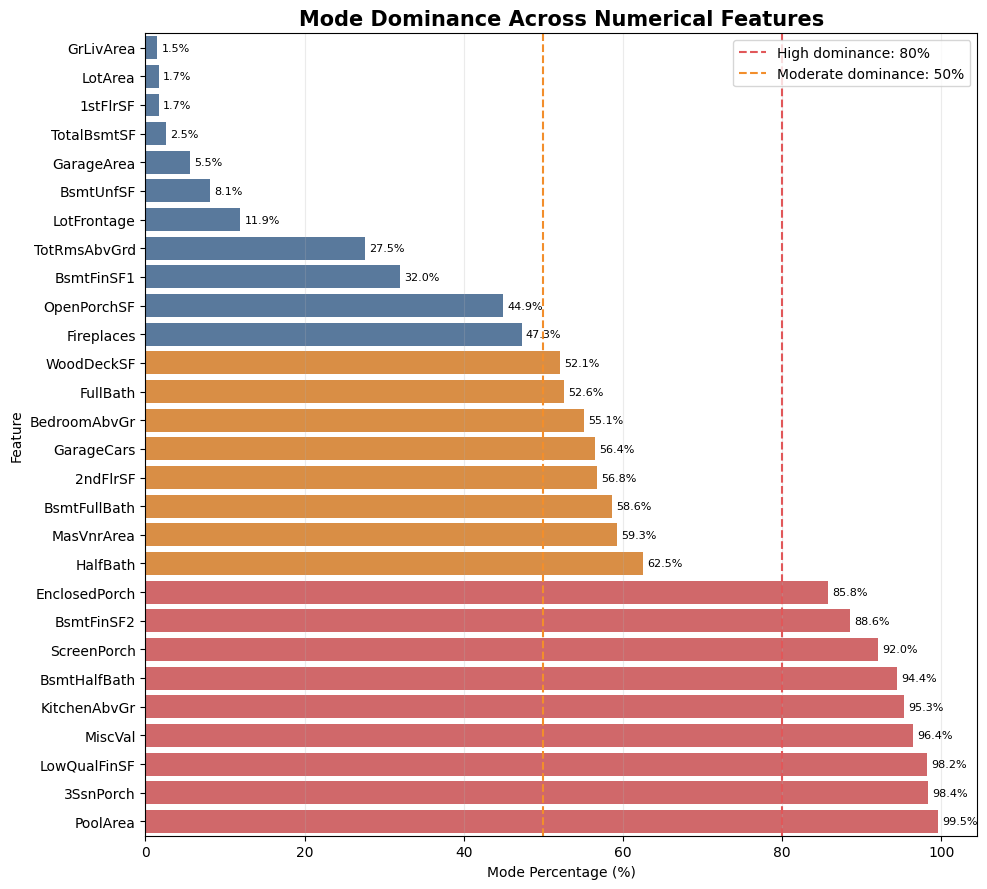

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

mode_plot_df = numeric_central_tendency_report.sort_values(
    "mode_percentage",
    ascending=True
)

plt.figure(figsize=(10, 9))

colors = mode_plot_df["mode_percentage"].apply(
    lambda x: "#E15759" if x >= 80 else "#F28E2C" if x >= 50 else "#4E79A7"
)

ax = sns.barplot(
    data=mode_plot_df,
    x="mode_percentage",
    y="column_name",
    palette=colors.tolist()
)

plt.title("Mode Dominance Across Numerical Features", fontsize=15, fontweight="bold")
plt.xlabel("Mode Percentage (%)")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=8)

plt.axvline(80, color="#E15759", linestyle="--", linewidth=1.5, label="High dominance: 80%")
plt.axvline(50, color="#F28E2C", linestyle="--", linewidth=1.5, label="Moderate dominance: 50%")

plt.grid(axis="x", alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

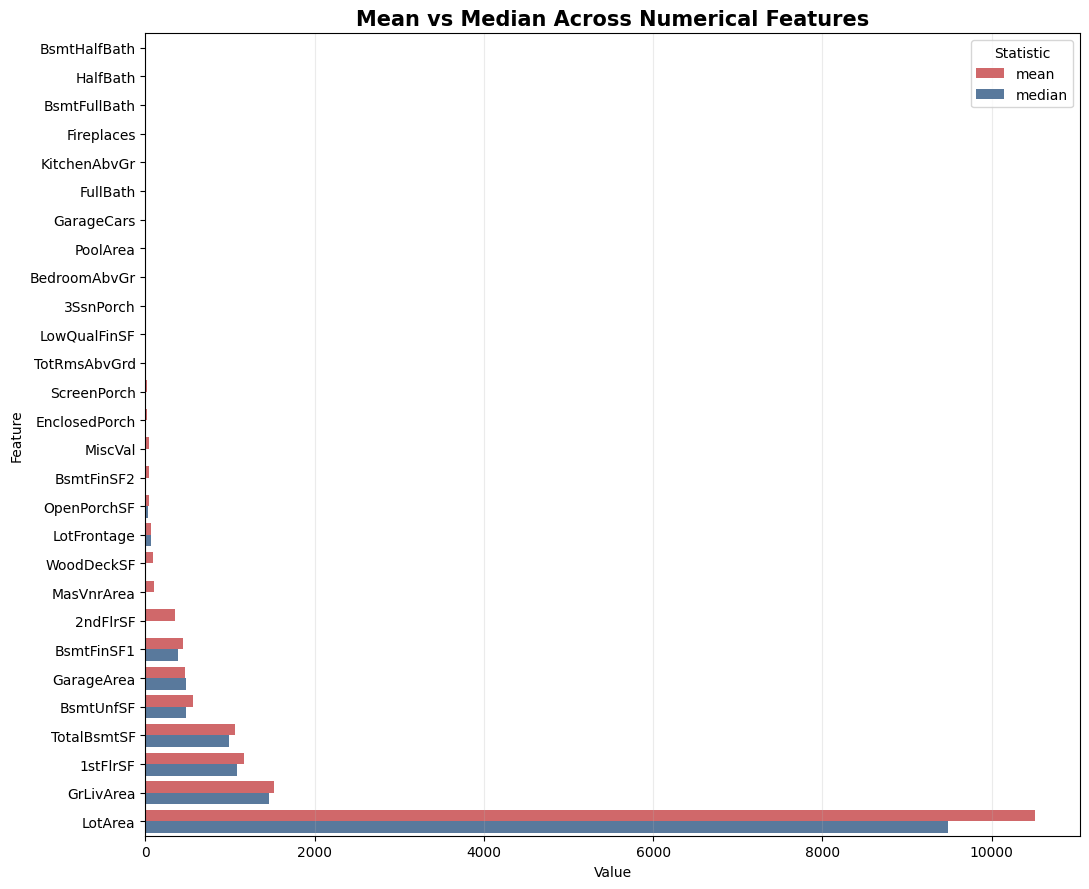

In [103]:
mean_median_plot_df = numeric_central_tendency_report[
    ["column_name", "mean", "median"]
].copy()

mean_median_plot_df = mean_median_plot_df.sort_values("mean", ascending=True)

mean_median_melted = mean_median_plot_df.melt(
    id_vars="column_name",
    value_vars=["mean", "median"],
    var_name="statistic",
    value_name="value"
)

plt.figure(figsize=(11, 9))

ax = sns.barplot(
    data=mean_median_melted,
    x="value",
    y="column_name",
    hue="statistic",
    palette={
        "mean": "#E15759",
        "median": "#4E79A7"
    }
)

plt.title("Mean vs Median Across Numerical Features", fontsize=15, fontweight="bold")
plt.xlabel("Value")
plt.ylabel("Feature")

plt.grid(axis="x", alpha=0.25)
plt.legend(title="Statistic")
plt.tight_layout()
plt.show()

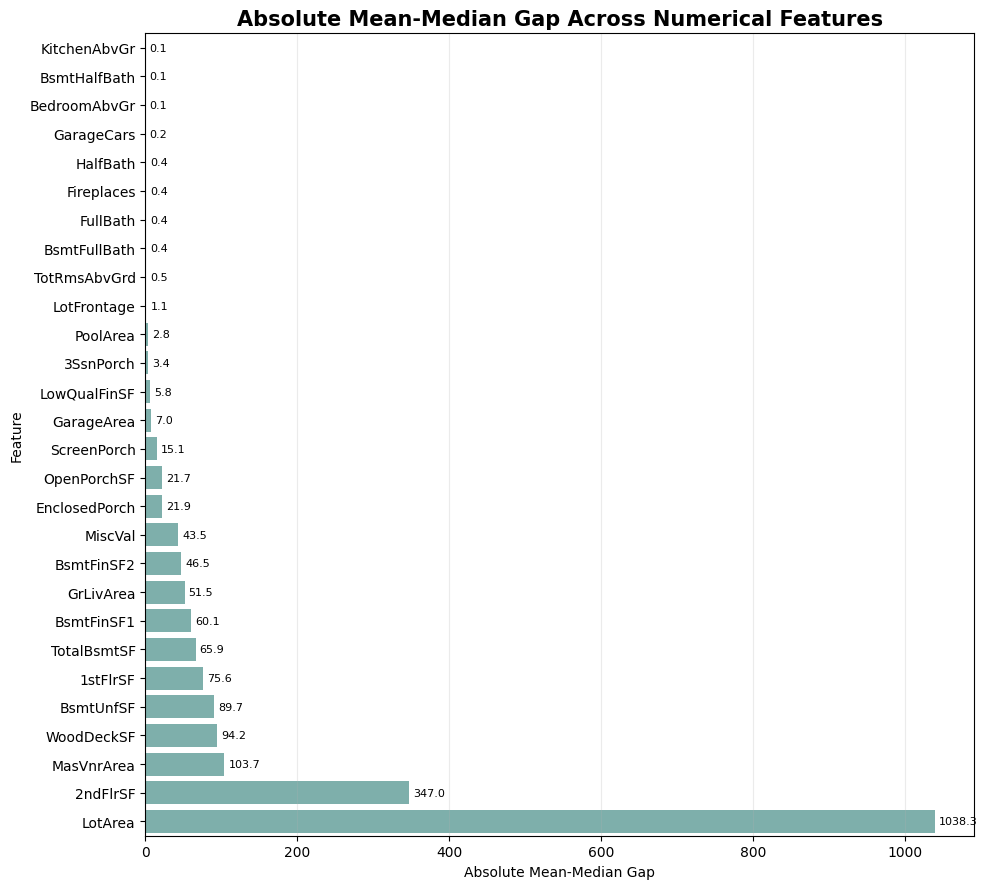

In [104]:
gap_plot_df = numeric_central_tendency_report.copy()
gap_plot_df["abs_mean_median_gap"] = gap_plot_df["mean_median_gap"].abs()

gap_plot_df = gap_plot_df.sort_values("abs_mean_median_gap", ascending=True)

plt.figure(figsize=(10, 9))

ax = sns.barplot(
    data=gap_plot_df,
    x="abs_mean_median_gap",
    y="column_name",
    color="#76B7B2"
)

plt.title("Absolute Mean-Median Gap Across Numerical Features", fontsize=15, fontweight="bold")
plt.xlabel("Absolute Mean-Median Gap")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### 3.5 Numeric Spread Report

In this section, we will analyze the spread of the 28 main numerical features.
We will check min, max, range, variance, standard deviation, quartiles, IQR, IQR bounds, and robust spread using MAD.

In [105]:
import numpy as np
import pandas as pd

def create_numeric_spread_report(df, numeric_cols):
    rows = []

    for col in numeric_cols:
        s = df[col].dropna()

        min_value = s.min()
        max_value = s.max()
        range_value = max_value - min_value

        variance_value = s.var()
        std_value = s.std()

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        median_value = s.median()
        mad = np.median(np.abs(s - median_value))
        robust_mad = 1.4826 * mad

        iqr_to_range_ratio = iqr / range_value if range_value != 0 else 0

        if range_value == 0:
            spread_level = "no spread"
        elif iqr == 0 and mad == 0:
            spread_level = "very low spread"
        elif iqr_to_range_ratio < 0.05:
            spread_level = "low spread"
        elif iqr_to_range_ratio < 0.25:
            spread_level = "moderate spread"
        else:
            spread_level = "wide spread"

        rows.append({
            "column_name": col,
            "min": round(min_value, 2),
            "max": round(max_value, 2),
            "range": round(range_value, 2),
            "variance": round(variance_value, 2),
            "std": round(std_value, 2),
            "q1": round(q1, 2),
            "q3": round(q3, 2),
            "iqr": round(iqr, 2),
            "lower_iqr_bound": round(lower_bound, 2),
            "upper_iqr_bound": round(upper_bound, 2),
            "mad": round(mad, 2),
            "robust_mad": round(robust_mad, 2),
            "iqr_to_range_ratio": round(iqr_to_range_ratio, 4),
            "spread_level": spread_level
        })

    return pd.DataFrame(rows)

In [106]:
numeric_spread_report = create_numeric_spread_report(
    df=train_df,
    numeric_cols=pure_numeric_cols
)

numeric_spread_report

,column_name,min,max,range,variance,std,q1,q3,iqr,lower_iqr_bound,upper_iqr_bound,mad,robust_mad,iqr_to_range_ratio,spread_level
0,LotFrontage,21.0,313.0,292.0,589.75,24.28,59.00,80.00,21.00,27.50,111.50,11.0,16.31,0.0719,moderate spread
1,LotArea,1300.0,215245.0,213945.0,99625649.65,9981.26,7553.50,11601.50,4048.00,1481.50,17673.50,1998.0,2962.23,0.0189,low spread
2,MasVnrArea,0.0,1600.0,1600.0,32784.97,181.07,0.00,166.00,166.00,-249.00,415.00,0.0,0.00,0.1038,moderate spread
3,BsmtFinSF1,0.0,5644.0,5644.0,208025.47,456.10,0.00,712.25,712.25,-1068.38,1780.62,383.5,568.58,0.1262,moderate spread
4,BsmtFinSF2,0.0,1474.0,1474.0,26023.91,161.32,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0000,very low spread
5,BsmtUnfSF,0.0,2336.0,2336.0,195246.41,441.87,223.00,808.00,585.00,-654.50,1685.50,288.0,426.99,0.2504,wide spread
6,TotalBsmtSF,0.0,6110.0,6110.0,192462.36,438.71,795.75,1298.25,502.50,42.00,2052.00,234.5,347.67,0.0822,moderate spread
7,1stFlrSF,334.0,4692.0,4358.0,149450.08,386.59,882.00,1391.25,509.25,118.12,2155.12,234.5,347.67,0.1169,moderate spread
8,2ndFlrSF,0.0,2065.0,2065.0,190557.08,436.53,0.00,728.00,728.00,-1092.00,1820.00,0.0,0.00,0.3525,wide spread
9,LowQualFinSF,0.0,572.0,572.0,2364.20,48.62,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.0000,very low spread


In [107]:
numeric_spread_report.sort_values(
    by=["spread_level", "iqr", "range"],
    ascending=[True, False, False]
)

,column_name,min,max,range,variance,std,q1,q3,iqr,lower_iqr_bound,upper_iqr_bound,mad,robust_mad,iqr_to_range_ratio,spread_level
1,LotArea,1300.0,215245.0,213945.0,99625649.65,9981.26,7553.50,11601.50,4048.00,1481.50,17673.50,1998.0,2962.23,0.0189,low spread
3,BsmtFinSF1,0.0,5644.0,5644.0,208025.47,456.10,0.00,712.25,712.25,-1068.38,1780.62,383.5,568.58,0.1262,moderate spread
10,GrLivArea,334.0,5642.0,5308.0,276129.63,525.48,1129.50,1776.75,647.25,158.62,2747.62,326.0,483.33,0.1219,moderate spread
7,1stFlrSF,334.0,4692.0,4358.0,149450.08,386.59,882.00,1391.25,509.25,118.12,2155.12,234.5,347.67,0.1169,moderate spread
6,TotalBsmtSF,0.0,6110.0,6110.0,192462.36,438.71,795.75,1298.25,502.50,42.00,2052.00,234.5,347.67,0.0822,moderate spread
20,GarageArea,0.0,1418.0,1418.0,45712.51,213.80,334.50,576.00,241.50,-27.75,938.25,120.0,177.91,0.1703,moderate spread
21,WoodDeckSF,0.0,857.0,857.0,15709.81,125.34,0.00,168.00,168.00,-252.00,420.00,0.0,0.00,0.1960,moderate spread
2,MasVnrArea,0.0,1600.0,1600.0,32784.97,181.07,0.00,166.00,166.00,-249.00,415.00,0.0,0.00,0.1038,moderate spread
22,OpenPorchSF,0.0,547.0,547.0,4389.86,66.26,0.00,68.00,68.00,-102.00,170.00,25.0,37.06,0.1243,moderate spread
0,LotFrontage,21.0,313.0,292.0,589.75,24.28,59.00,80.00,21.00,27.50,111.50,11.0,16.31,0.0719,moderate spread


In [108]:
numeric_spread_summary = (
    numeric_spread_report["spread_level"]
    .value_counts()
    .reset_index()
)

numeric_spread_summary.columns = ["spread_level", "feature_count"]

numeric_spread_summary

,spread_level,feature_count
0,moderate spread,11
1,very low spread,9
2,wide spread,7
3,low spread,1


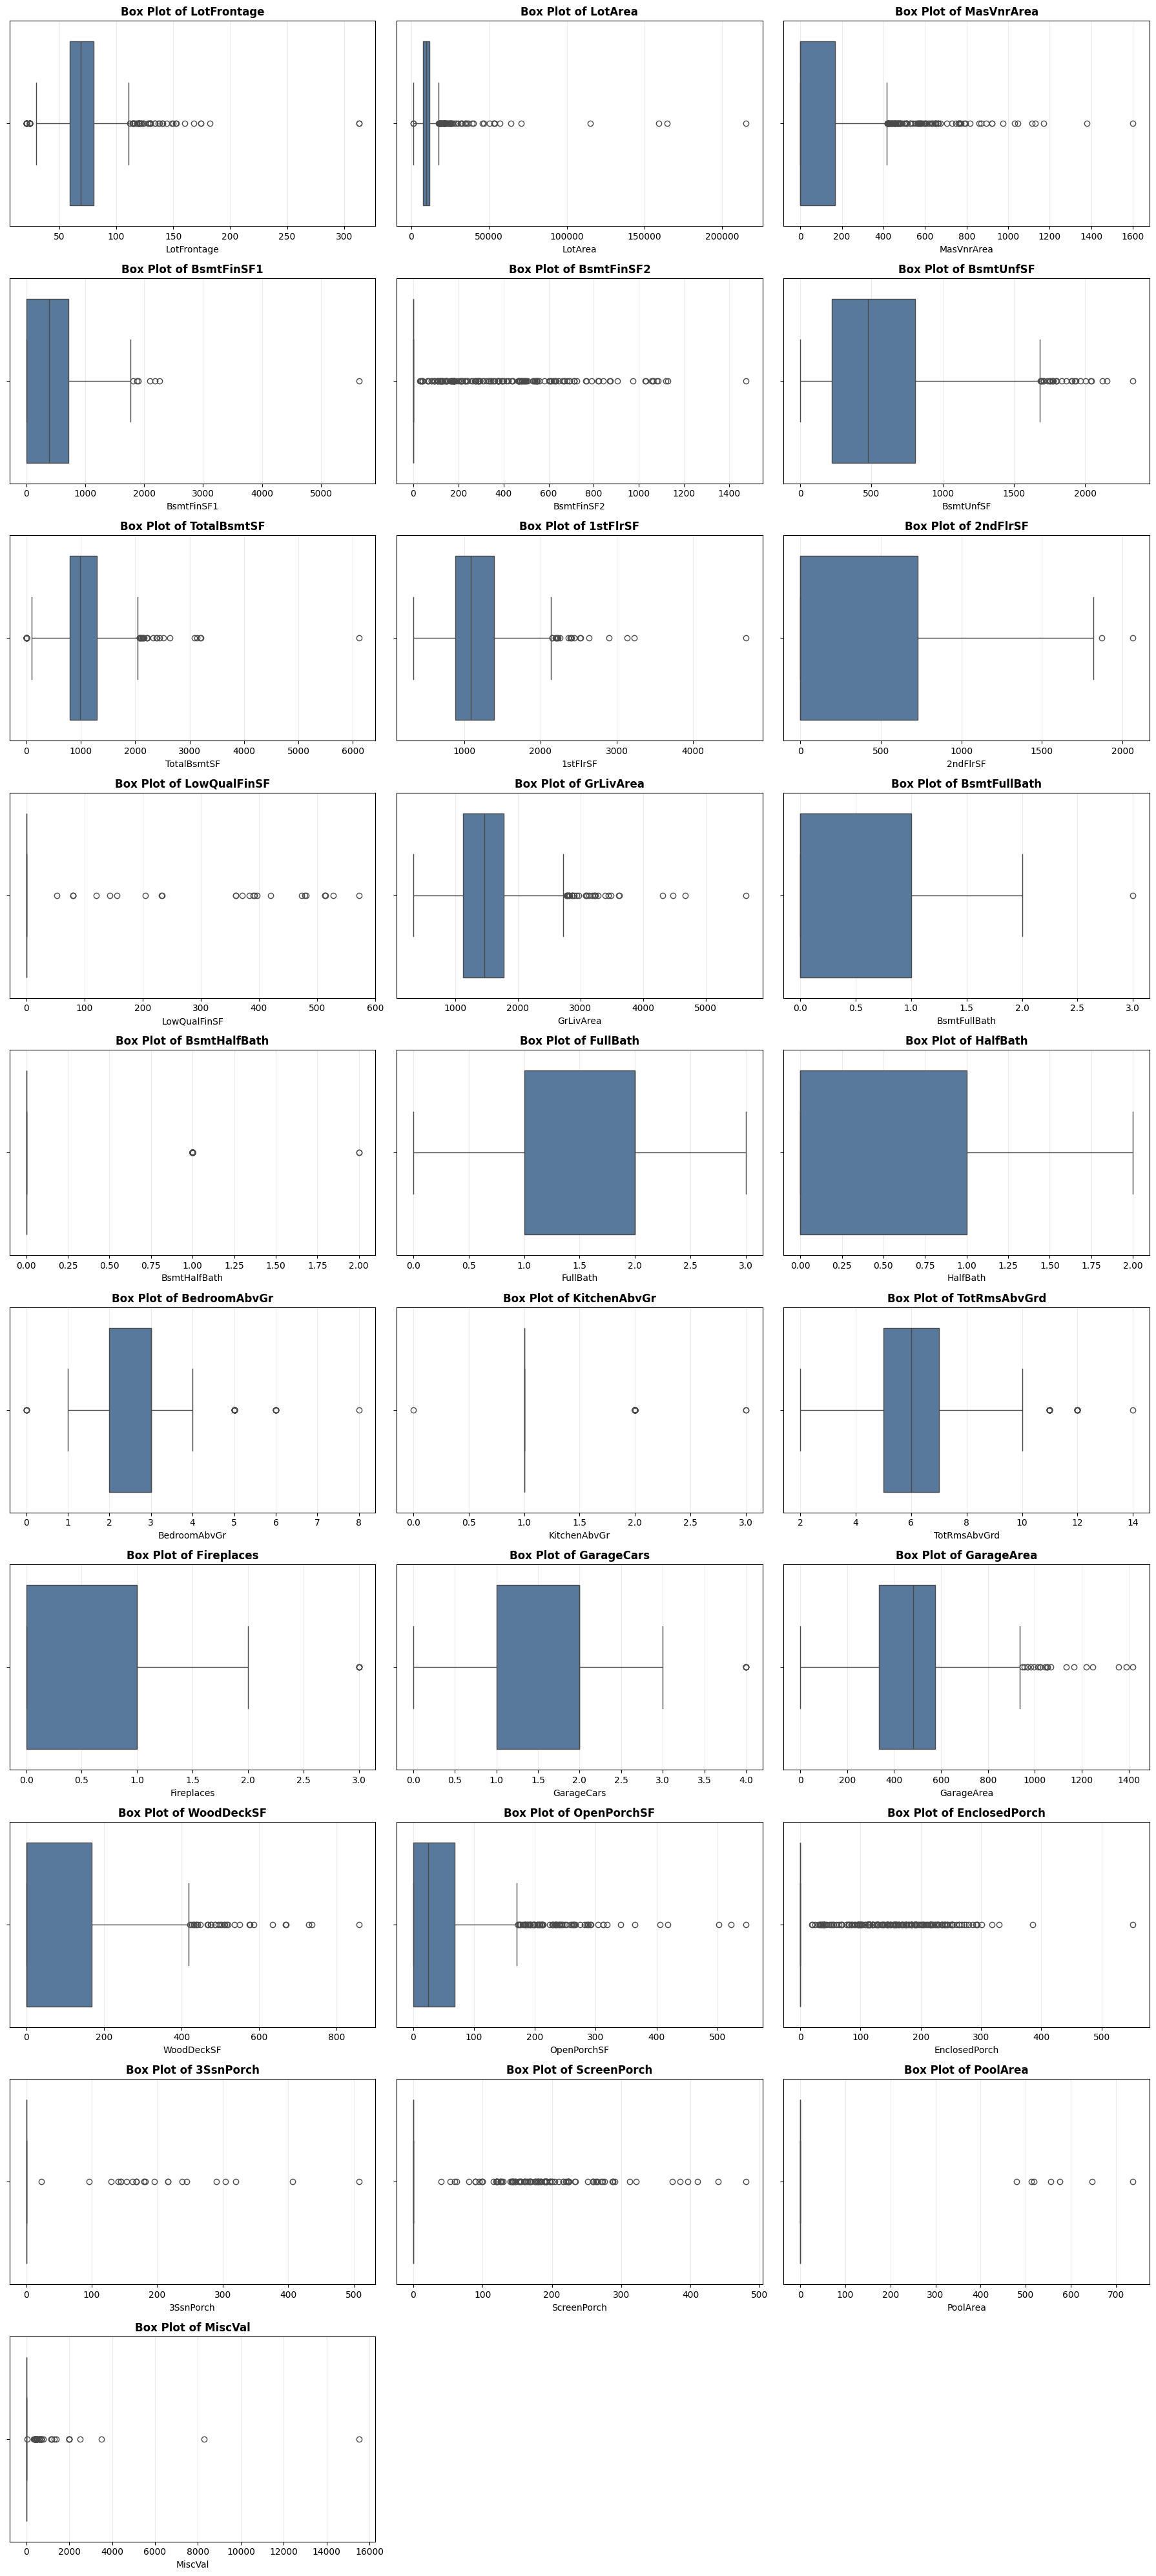

In [109]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = math.ceil(len(pure_numeric_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(pure_numeric_cols):
    sns.boxplot(
        x=train_df[col],
        ax=axes[i],
        color="#4E79A7"
    )

    axes[i].set_title(f"Box Plot of {col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].grid(axis="x", alpha=0.25)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

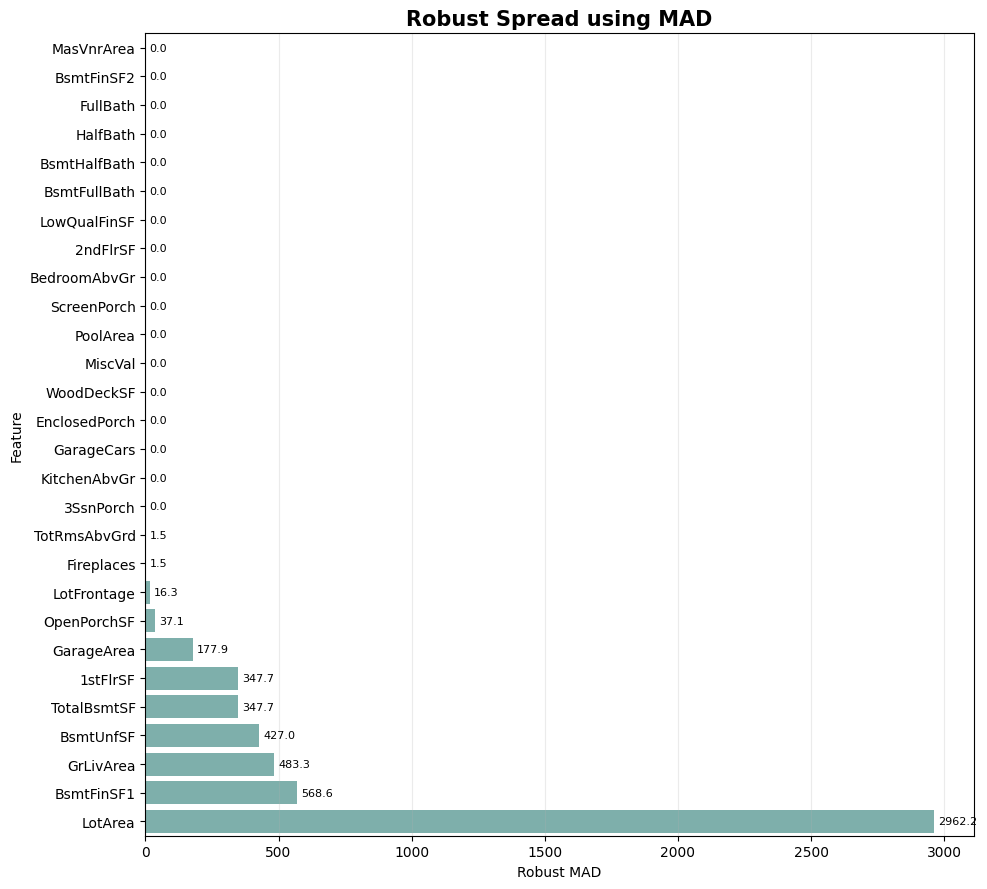

In [110]:
mad_plot_df = numeric_spread_report.sort_values(
    by="robust_mad",
    ascending=True
)

plt.figure(figsize=(10, 9))

ax = sns.barplot(
    data=mad_plot_df,
    x="robust_mad",
    y="column_name",
    color="#76B7B2"
)

plt.title("Robust Spread using MAD", fontsize=15, fontweight="bold")
plt.xlabel("Robust MAD")
plt.ylabel("Feature")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)

plt.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

### Numeric Spread Report - Key Findings

The box plots show that many numerical features are strongly right-skewed and contain upper-side outliers, especially `LotArea`, `GrLivArea`, `GarageArea`, `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`, `ScreenPorch`, `PoolArea`, and `MiscVal`.

The MAD chart shows that `LotArea` has the highest robust spread by far, followed by `BsmtFinSF1`, `GrLivArea`, `BsmtUnfSF`, `TotalBsmtSF`, and `1stFlrSF`, meaning these features have wider natural variation and should be handled carefully during scaling or transformation.

Many zero-heavy features such as `MasVnrArea`, `BsmtFinSF2`, `LowQualFinSF`, `2ndFlrSF`, `ScreenPorch`, `PoolArea`, `MiscVal`, and porch-related features have MAD close to `0`; this does not mean they are useless, but it means most values are concentrated at `0`.

Overall, wide-spread and skewed features should be considered for `log1p` or robust scaling, while zero-dominated features should get binary indicator features such as `HasPool`, `HasScreenPorch`, `HasWoodDeck`, or `HasMiscVal`.